# Data Analysis and Processing Notebook

Project : Accessibility and quality of emergency medical services under decentralization policy

Author : P. Sitthirat et al.

This notebook serves as a comprehensive guide for processing and analyzing the impact of the decentralization policy on emergency medical services. It includes data cleaning, manipulation, and analysis.

Objectives:
- Processing the national database on EMS.
- Evaluating the accessibility and quality of EMS before and after decentralization.
- Identifying key metrics and trends in EMS performance.
- Conducting statistical and time series analyses to assess policy impact.

Requirements: Ensure the following libraries are installed before running the notebook: `pip install -r scripts/requirements.txt`

## Overview

This notebook is structured into several key sections:
- **Data Loading and Preprocessing**: Importing and cleaning the ITEMS database for analysis.
- **Descriptive Statistical Analysis**: Summarizing key demographic and operational metrics.
- **Comparative Analysis** Examining differences in EMS performance metrics between decentralized and non-decentralized provinces.
- **Time Series Analysis**: Assessing temporal trends before and after decentralization.
- **Logistic Regression Analysis**: Evaluating factors influencing survival outcomes.
- **Visualization**: Presenting results through graphs and tables.
- **Output**: Saving processed data and results for further use.

## 1. Initial Setup and Library Imports

This cell initializes the notebook with necessary configurations and imports key libraries and custom modules for data processing, analysis, and visualization.

### Features:
1. **IPython Extensions**:
- `%load_ext autoreload`: Automatically reloads modules before executing cells, ensuring the latest code changes are applied.
- `%autoreload 2`: Reloads all imported modules every time a cell is executed.

2. **Library Imports**:
- `pandas`: For data manipulation and analysis.
- `numpy`: For numerical operations.
- `warnings`: To handle and suppress warnings.
- `matplotlib`: For visualization

3. **Custom Modules** from scripts folder:
- `process`: For data cleaning and processing.
- `skim`: For assessing data quality.
- `analyse`: For performing data analysis.
- `graph`: For creating visualizations.

4. **Notebook Settings**:
- `pd.set_option('future.no_silent_downcasting', True)`: Ensures that pandas raises warnings for downcasting operations.
- `warnings.simplefilter('ignore', FutureWarning)`: Suppresses future warnings for a cleaner output.
- `warnings.simplefilter('ignore', SyntaxWarning)`: Suppresses syntax warnings for a cleaner output.
- `warnings.simplefilter('ignore', DeprecationWarning)`: Suppresses deprecation warnings for a cleaner output.
- `pd.options.display.max_columns = None`: Displays all columns in pandas DataFrames for better visibility.

### Code:
This configuration ensures an efficient and clean working environment for data analysis and processing.

In [1]:
%load_ext autoreload
%autoreload 2

# Import library
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from scripts import process
from scripts import skim
from scripts import analyse

import seaborn as sns

from IPython.display import clear_output
pd.set_option('future.no_silent_downcasting', True)
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', SyntaxWarning)
warnings.simplefilter('ignore', DeprecationWarning)
pd.options.display.max_columns = None

# 2. Import, Clean, and Manipulate the Dataset
## 2.1 The National Level Data
The dataset is extracted from the Information Technology for Emergency Medical Services (ITEMS) database, It spans two fiscal years (October 2021 to September 2023) and is divided into two sources:
- ITEMS: Data from October 2021 to November 2022.
- ITEMS 4.0: Data from December 2022 to September 2023.

### 2.1.1 ITEMS
The objective here is to process and prepare the data from the ITEMS system for analysis. This involves cleaning, creating derived variables, and validating the data through the following steps:
1. **Data Import and Initial Cleaning** 
   - Load and clean the raw data using the custom `process.DataCleaning` module.
   - Generate a data dictionary in the `data/ITEMS/OVERALL` folder to understand variable types and mappings.
   - Update column names based on a validation dictionary for standardization.
   - Validate and convert column data types, correcting errors as needed. All corrections are documented in the `output/errors` folder, which includes the 'error' data points and their 'edited' versions.
   - Remove 1,101 duplicate rows to ensure data consistency. 
2. **Further Cleaning and Transformation**: After the initial cleaning, additional steps were performed:
   - **Calculate Duration Metrics**: Generate key time metrics to measure EMS performance:
      - **Dispatch time** (`dur_dispatch`): Time from the emergency call to dispatch command.
      - **Activation time** (`dur_activation`): Time from dispatch command to ambulance departure.
      - **Response time** (`dur_response`): Time from the call to ambulance arrival at the scene.
      - **Scene time** (`dur_scene`): Time spent at the scene before leaving for the hospital.
      - **Transport time** (`dur_transport`): Time from leaving the scene to arriving at the hospital.
      - **Prehospital time** (`dur_prehos`): Time from the call to arrival at the emergency department.
   - **Handling Missing Data**: Fill missing values for provinces and hospitals using related columns for reference.
   - **Categorical Data Mapping**: Translate and group categorical variables using mapping files stored in `output/map`.
   - **Numerical Data Validation**: Mark values exceeding the 99th percentile as null to handle outliers.
   - **Outcome Validation (`dead`)**:
      - Mark a patient as deceased if 
         - declared dead at the scene (`result_op`) and any outcome at the emergency department.
         - at the emergency department (`result_hos`) with any outcome (not dead) or null at the scene.
      - Mark a patient as survived if explicitly indicated as survived in either operation or ED records.
      - Leave the outcome as "none" if both `result_op` and `result_hos` are unavailable.
   - **Performance Grouping**: Categorize performance metrics based on these benchmarks:
      - Dispatch time < 1 minute.
      - Activation time < 2 minutes.
      - Response time < 8 minutes.

Finally, the DataFrame will be saved as `df_items` for further analysis.

In [4]:
# Import ITEMS Oct 2021 - Nov 2022
data_dir = 'data/ITEMS/OVERALL'
file_name = 'ITEMS_202110-202211'
output_dir = 'output'

df_clean, df_raw, dict_path = process.DataCleaning.clean(file_name, data_dir, output_dir, export_df=False)

File name                : ITEMS_202110-202211
Path to data dictionary  : data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx
Path to cleaned dataset  : None


In [5]:
## Adding the calculated columns

df = df_clean.copy()

# Fill null scene departure time with hospital time
start = pd.to_datetime('2021-10-01')
end = pd.to_datetime('2022-11-30')
for time_col in ['date', 'time', 'time_call', 'time_dispatch', 'time_outbase', 'time_arrive', 'time_scenedept', 'time_hosp', 'time_basereturn']:
    df[time_col] = df[time_col].apply(lambda x: x if start <= x <= end else None)
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

# Create the duration parameters
df['dur_dispatch'] = df.apply(lambda row: (row['time_dispatch'] - row['time_call']).total_seconds() / 60, axis=1)
df['dur_activation'] = df.apply(lambda row: (row['time_outbase'] - row['time_dispatch']).total_seconds() / 60, axis=1)
df['dur_response'] = df.apply(lambda row: (row['time_arrive'] - row['time_call']).total_seconds() / 60, axis=1)
df['dur_scene'] = df.apply(lambda row: (row['time_scenedept'] - row['time_arrive']).total_seconds() / 60, axis=1)
df['dur_transport'] = df.apply(lambda row: (row['time_hosp'] - row['time_scenedept']).total_seconds() / 60, axis=1)
df['dur_prehos'] = df.apply(lambda row: row['dur_response']+row['dur_scene']+row['dur_transport'], axis=1)

# Create province and hospital data columns
df['prov'] = df['location'].apply(lambda x: x.split()[0] if pd.notna(x) else None)
df = process.DataManipulation.fill_missing(df, 'prov', ['unit_name', 'hosp', 'unit_sub'])

df[['hosp_name', 'hosp_code', 'unit_code']] = df['hosp'].apply(
    lambda x: pd.Series(process.DataManipulation.str_split(x, r"^(.*?) \(/\s*(\d+)\s*/\) \[(.*?)\]$", number_of_groups = 3)))
df = process.DataManipulation.fill_missing(df, 'hosp_code', ['hosp'])
df['hosp_code'] = df['hosp_code'].apply(lambda x: str(int(x)) if pd.notna(x) else None)

# Update the dataframe
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)
skim.skim(df, df_raw, "ITEMS after adding the columns")
df_clean = df.copy()

Missing values in prov: 4 (0.00%)
Missing values in hosp_code: 130316 (6.01%)


Creating dictionary: 100%|██████████| 98/98 [00:21<00:00,  4.64it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after adding the columns
Number of rows           : 2168446
Number of columns        : 98

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 2169547
Number of duplicated rows: 2081
Variable types:
   object              84
   float64             4

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 2168446
Number of incomplete rows: 2168446 (100.00%)
Variable types:
   float64             40
   object              35
   string              14
   datetime64[ns]      9

── Variable type: float64 ──────────────────────────────────────────────────────
skim_variable           n_missing    complete_rate            mean               sd         p0    p1    p10    p25    p50    

In [6]:
## Manipulating the data

df = df_clean.copy()
columns = pd.read_excel(dict_path, sheet_name="validate")
include = columns[columns['Include'] == True][['Column Name']]
col_include = include['Column Name'].tolist()

# Manipulate the data from each 
for _, row in columns.iterrows():
    col = row['Column Name']
    data_type = row['Data Type']
    map = row['Map']
    outlier = row['OutlierDetect']
    minimum = row['Min']
    
    if data_type == 'object' and map == True:
        df = process.DataManipulation.mapping(df, col)
    elif data_type in ['float64', 'timedelta64[ns]']:
        if pd.notna(minimum):
            df[col] = df[col].apply(lambda x: x if x >= minimum else None)
            if outlier == True:
                df, modified = process.DataManipulation.outlier_percentile(df, col, percentile=99, direction='more than', impute=None, print_outliers=False)

# Validate the result
df['dead'] = df.apply(
    lambda row: (
        'dead' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
        'dead' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['dead_gr'] = df.apply(
    lambda row: (
        'dead at scene' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
        'dead at hos' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['triage_er'] = np.where(df['dead_gr'] == 'death at scene', 'dead', df['triage_er'])

# Grouping the performance
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)

# Identify the source
df['source'] = 'ITEMS'

# Update the dictionary
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)

# Extract only the included columns
df_include = df[col_include].copy()
skim.skim(df_include, df_raw, "ITEMS after manipulation")

# Declare the items data as DataFrame for further analysis
df_items = df_include.copy()

Creating dictionary: 100%|██████████| 104/104 [00:21<00:00,  4.84it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202110-202211.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after manipulation
Number of rows           : 2168446
Number of columns        : 28

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 2169547
Number of duplicated rows: 2081
Variable types:
   object              84
   float64             4

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 2168446
Number of incomplete rows: 539077 (24.86%)
Variable types:
   object              17
   float64             10
   datetime64[ns]      1

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------

### 2.1.2 ITEMS 4.0
ITEMS 4.0 is the upgraded operational system for ITEMS, with data hosted on a new cloud infrastructure. The structure and variables differ significantly from the older ITEMS system, necessitating a tailored cleaning process.
1. **Data Import and Initial Cleaning** 
   - Load and clean the raw data using the custom `process.DataCleaning` module.
   - Generate a data dictionary in the `data/ITEMS/OVERALL` folder to understand variable types and mappings.
   - Update column names based on a validation dictionary for standardization.
   - Validate and convert column data types, correcting errors as needed. All corrections are documented in the `output/errors` folder, which includes the 'error' data points and their 'edited' versions.
   - Remove 334 duplicate rows to ensure data consistency. 
2. **Further Cleaning and Transformation**: After the initial cleaning, additional steps were performed:
   - **Generate Relevant Metrics**:
      - **Shift** (`shift`): Categorize the time of call into three shifts:
         - Morning (8:00 AM–4:00 PM)
         - Afternoon (4:00 PM–12:00 AM)
         - Night (12:00 AM–8:00 AM)
      - **Hospital ID** (`hosp_code`): Extract hospital information from the `hosp` field.
      - **Age** (`age`): Calculate age from `age_ext`, which separates age in years and months using the "|" delimiter.
      - **Duration metrics**: compute key time durations as detailed in Section [2.1.1](#211-items), including dispatch time, activation time, response time, and others.
   - **Mapping and Validation**: Apply the same mapping and validation processes as used for ITEMS (refer to Section [2.1.1](#211-items)).

Finally, the DataFrame will be saved as `df_items40` for further analysis.

In [7]:
# Import ITEMS Dec 2022 - Sep 2023
data_dir = 'data/ITEMS/OVERALL'
file_name = 'ITEMS_202212-202309'
output_dir = 'output'

df_clean, df_raw, dict_path = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

File name                : ITEMS_202212-202309
Path to data dictionary  : data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx
Path to cleaned dataset  : None


In [8]:
## Adding the calculated columns

df = df_clean.copy()

# Fill null scene departure time with hospital time
start = pd.to_datetime('2022-12-01')
end = pd.to_datetime('2023-12-31')
for time_col in ['date', 'time_call', 'time_dispatch', 'time_outbase', 'time_arrive', 'time_scenedept', 'time_hosp', 'time_basereturn']:
    df[time_col] = df[time_col].apply(lambda x: x if start <= x <= end else None)
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

def shifting(time_variable):
    if pd.isnull(time_variable):
        return None
    else:
        hour = time_variable.hour
        if 0 <= hour < 8:
            return 'night'
        elif 8 <= hour < 16:
            return 'morning'
        elif 16 <= hour <= 23:
            return 'afternoon'
        else:
            return None
df['shift'] = df.apply(
    lambda row: shifting(row['time_call']) if pd.notnull(row['time_call'])
    else (shifting(row['time_arrive']) if pd.notnull(row['time_arrive'])
          else shifting(row['time_hosp'])),
    axis=1
)

df['prov'] = df.apply(lambda row: row['prov'] if pd.notnull(row['prov']) else row['prov_command'], axis=1)

df['hosp_code'] = None
df = process.DataManipulation.fill_missing(df, 'hosp_code', ['hosp'])
df['hosp_code'] = df['hosp_code'].astype(object)

# Function to convert 'year|month' to float representing years
def convert_age(age_str):
    if pd.isnull(age_str) or age_str == '':
        return None  # Return None for missing or empty values
    try:
        parts = age_str.split('|')
        years = float(parts[0]) if parts[0] else 0
        months = float(parts[1]) if len(parts) > 1 and parts[1] else 0
        return years + months / 12
    except ValueError:
        return None  # Return None if conversion fails
df['age'] = df['age_ext'].apply(convert_age)

# Create the duration parameters
df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])

def duration(df, col1, col2):
    """
    Calculate the duration in minutes between two columns.
    Returns None if either column value is null.
    
    Parameters:
    - df: The DataFrame containing the data.
    - col1: The name of the first column (start time).
    - col2: The name of the second column (end time).
    
    Returns:
    - A Series with the calculated durations in minutes.
    """
    return df.apply(
        lambda row: (row[col2] - row[col1]).total_seconds() / 60 
        if pd.notnull(row[col1]) and pd.notnull(row[col2]) 
        else None, 
        axis=1
    )

# Calculate all durations using the function
df['dur_dispatch'] = duration(df, 'time_call', 'time_dispatch')
df['dur_activation'] = duration(df, 'time_dispatch', 'time_outbase')
df['dur_response'] = duration(df, 'time_call', 'time_arrive')
df['dur_scene'] = duration(df, 'time_arrive', 'time_scenedept')
df['dur_transport'] = duration(df, 'time_scenedept', 'time_hosp')

# Calculate total prehospital duration
df['dur_prehos'] = df['dur_response'] + df['dur_scene'] + df['dur_transport']


# Update the dataframe
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)
skim.skim(df, df_raw, "ITEMS4.0 after adding the columns")
df_clean = df.copy()

Missing values in hosp_code: 70764 (5.29%)


Creating dictionary: 100%|██████████| 57/57 [00:08<00:00,  6.86it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS4.0 after adding the columns
Number of rows           : 1336870
Number of columns        : 57

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 1337204
Number of duplicated rows: 668
Variable types:
   object              45
   float64             3

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 1336870
Number of incomplete rows: 1336870 (100.00%)
Variable types:
   object              36
   float64             10
   datetime64[ns]      8
   string              3

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  -------

In [9]:
## Manipulating the data

df = df_clean.copy()
columns = pd.read_excel(dict_path, sheet_name="validate")
include = columns[columns['Include'] == True][['Column Name']]
col_include = include['Column Name'].tolist()

# Process columns based on data type
for _, row in columns.iterrows():
    col = row['Column Name']
    data_type = row['Data Type']
    map = row['Map']
    outlier = row['OutlierDetect']
    minimum = row['Min']
    
    if data_type == 'object' and map == True:
        df = process.DataManipulation.mapping(df, col)
    elif data_type in ['float64', 'timedelta64[ns]']:
        if pd.notna(minimum):
            df[col] = df[col].apply(lambda x: x if pd.notna(x) and x >= minimum else None)
            if outlier == True:
                df, modified = process.DataManipulation.outlier_percentile(df, col, percentile=99, direction='more than', impute=None, print_outliers=False)

# Validate the result
df['dead'] = df.apply(
    lambda row: (
        'dead' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
        'dead' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['dead_gr'] = df.apply(
    lambda row: (
        'dead at scene' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
        'dead at hos' if row['result_hos'] == 'dead' else
        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
        None
    ), axis=1)
df['triage_er'] = np.where(df['dead_gr'] == 'death at scene', 'dead', df['triage_er'])

# Grouping the performance
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)

df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)

df['response'] = df['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)

# Identify the source
df['source'] = 'ITEMS4.0'

# Update the dictionary
dict_path = process.DataHandler.create_dictionary(df, file_name, data_dir)

# Extract only the included columns
df_include = df[col_include].copy()
skim.skim(df_include, df_raw, "ITEMS after manipulation")

# Declare the items data as DataFrame for further analysis
df_items40 = df_include.copy()

Creating dictionary: 100%|██████████| 63/63 [00:08<00:00,  7.04it/s]


Created data dictionary successfully: saved to data/ITEMS/OVERALL/data_dict-ITEMS_202212-202309.xlsx

── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS after manipulation
Number of rows           : 1336870
Number of columns        : 28

── Pre-processing Data ─────────────────────────────────────────────────────────
Number of rows           : 1337204
Number of duplicated rows: 668
Variable types:
   object              45
   float64             3

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 1336870
Number of incomplete rows: 560499 (41.93%)
Variable types:
   object              17
   float64             10
   datetime64[ns]      1

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  -------------------------------

### 2.1.3 Missing Analysis and Imputation
This section focuses on handling missing values in the combined ITEMS dataset, ensuring data completeness and consistency for subsequent analyses. The process involves merging datasets, analyzing missing data patterns, and imputing missing values using advanced statistical and machine learning methods.

1. **Combining Datasets**  
   - Merge the cleaned datasets `df_items` and `df_items40` into a single DataFrame (`df_combined`).
   - Add a `missing` column to flag rows with any missing values.
   - Standardize the `date` column format to `YYYY-MM-DD` for consistency.

2. **Initial Missing Data Analysis**  
   - Use the `skim` function to generate a comprehensive summary of the combined dataset.
   - Focus on key columns (e.g., demographic, operational, and performance metrics) to identify and visualize missing data patterns:
     - Perform MCAR (Missing Completely at Random) analysis to test randomness in missing data.
     - Visualize missing data patterns in primary columns using heatmaps.

3. **Detailed Missing Data Inspection**  
   - Filter out records:
     - Dates beyond `2023-07-31`.
     - Rows from Bangkok (`กรุงเทพมหานคร`) or missing provincial data.
   - Generate a summary of missing values, detailing:
     - Number of missing columns per record.
     - Specific columns with missing data.
   - Export the missing data summary to `output/analyse/00_missing_summary.csv`.

4. **Missing Data Imputation**  
   - Separate variables into **continuous** (numerical) and **categorical** groups for targeted imputation strategies:
     - **Continuous Variables**: Use correlations with other numerical variables and group-level differences for imputation.
     - **Categorical Variables**: Use logistic regression and proportional analysis for imputation.
   - Store results of correlation and analysis tests in `output/analyse/00_missing_correlation.csv`.
   - Iteratively impute missing values:
     - Use a Random Forest model to predict missing values based on significant features identified during analysis.
     - Perform up to 10 iterations or until the proportion of missing rows falls below 5%.

5. **Visualization of Imputation Results**  
   - Compare data before and after imputation:
     - **Continuous Variables**: Plot density distributions to assess the impact of imputation.
     - **Categorical Variables**: Use bar charts to visualize the distribution of original and imputed data, grouped by categories.

6. **Final Output**  
   - Export the imputed dataset as `ITEMS_imputed.csv` to `output/clean/`.
   - Save an intermediate dataset (`ITEMS_forimpute.csv`) for future reference.

In [10]:
df_combined = pd.concat([df_items, df_items40], ignore_index=True)
df_combined['missing'] = df_combined.isnull().any(axis=1)
df_combined['date'] = pd.to_datetime(df_combined['date']).dt.strftime('%Y-%m-%d')
skim.skim(df_combined, None, "ITEMS combined dataset")


── Data Summary ────────────────────────────────────────────────────────────────
Name                     : ITEMS combined dataset
Number of rows           : 3505316
Number of columns        : 29

── Variable Types ──────────────────────────────────────────────────────────────
Number of rows : 3505316
Number of incomplete rows: 1099576 (31.37%)
Variable types:
   object              18
   float64             10
   bool                1

── Variable type: object ───────────────────────────────────────────────────────
skim_variable      n_missing    complete_rate    n_unique  top_counts
---------------  -----------  ---------------  ----------  ------------------------------------------------------------------
activation            471626             0.87           2  {'<= 2 min': 2652758, '> 2 min': 380932}
call                   79015             0.98           3  {'call 1669': 3066886, 'radio': 302743, 'other': 56672}
date                       0             1            822  {'2023-

In [ ]:
primary_cols = ['call', 'date', 'dead_gr', 'gender', 'level', 'nationality', 'prov', 'shift', 'symptom_code', 'triage_er', 'triage_phone', 'triage_scene', 'type', 'age', 'distance_basetoscene', 'distance_hostobase', 'distance_scenetohos', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'dur_transport']
analyse.Missing.mcar(df_combined[primary_cols], alpha=0.05)
analyse.Missing.missing_visualize(df_combined[primary_cols], "ITEMS (primary columns)")

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

df = pd.read_csv('output/clean/ITEMS_forimpute.csv')
target_variable = 'dur_response'

# Separate rows where target is not missing
df_no_missing = df.dropna(subset=[target_variable])

# Identify numerical/categorical features
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Encode categorical features (One-Hot Encoding or Label Encoding)
df_encoded = pd.get_dummies(df_no_missing, columns=categorical_features, drop_first=True)

# Define predictors (exclude target variable)
predictors = [col for col in df_encoded.columns if col != target_variable]

# Train a Random Forest model to predict the target variable
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df_encoded[predictors], df_encoded[target_variable])

# Get feature importance scores
feature_importance = pd.DataFrame({'Feature': predictors, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

# Select top N features (e.g., top 10)
# top_features = feature_importance['Feature'][:10].tolist()
# print("Selected Features for Imputation:", top_features)

In [20]:
df = df_combined.copy()

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df[df['date'] <= pd.to_datetime('2023-07-31')]

df = df[(df['prov'] != 'กรุงเทพมหานคร') & pd.notna(df['prov'])]

# Check for missing values
missing = df[primary_cols].isnull()
n_missing = missing.sum(axis=1)
missing_columns = missing.apply(lambda row: ', '.join(missing.columns[row]), axis=1)
missing_summary = pd.DataFrame({
    'MissingCount': n_missing,
    'MissingColumns': missing_columns
})
missing_summary.to_csv('output/analyse/00_missing_summary.csv')

# Impute for numerical variable
all_vars = primary_cols
continuous_vars = [col for col in all_vars if df[col].dtype in ['int64', 'float64']]
categorical_vars = [col for col in all_vars if col not in continuous_vars]

# Results storage
results = []


for var in all_vars:
    if df[var].isnull().sum() > 0:
        print(f'Analysing predictor for {var}')
        features = [col for col in all_vars if col != var]
        if var in continuous_vars:
            for feature in features:
                if df[feature].dtype in ['int64', 'float64']:  # Numerical feature
                    corr, pvalue, interpretation = analyse.Difference.correlation(df, feature, var)
                    results.append({'Independent Variable': feature, 'Dependent Variable': var,
                                    'Measure': 'Spearman', 'P-Value': pvalue, 'Effect Size': corr, 'Interpretation': interpretation})
                else:  # Categorical feature
                    pvalue, eff, test, interpretation = analyse.Difference.numerical(df, factor=var, group_var=feature, independent=True)
                    results.append({'Independent Variable': feature, 'Dependent Variable': var,
                                    'Measure': test, 'P-Value': pvalue, 'Effect Size': eff, 'Interpretation': interpretation})
        if var in categorical_vars:
            for feature in features:
                if df[feature].dtype in ['int64', 'float64']:  # Numerical feature
                    pvalue, eff, test, interpretation = analyse.Regression.logistic_regression(df, independent_var=feature, dependent_var=var, export_as='parameters')
                    results.append({'Independent Variable': feature, 'Dependent Variable': var,
                                    'Measure': test, 'P-Value': pvalue, 'Effect Size': eff, 'Interpretation': interpretation})
                else:
                    pvalue, eff, test, interpretation = analyse.Difference.proportional(df, factor=var, group_var=feature)
                    results.append({'Independent Variable': feature, 'Dependent Variable': var,
                                    'Measure': test, 'P-Value': pvalue, 'Effect Size': eff, 'Interpretation': interpretation})
    else:
        print(f"No missing for {var}")

clear_output(wait=True)

results_df = pd.DataFrame(results)
results_df.to_csv('output/analyse/00_missing_correlation.csv')
display(results_df)

df_forimpute = df.copy()
df_forimpute.to_csv('output/clean/ITEMS_forimpute.csv')

,Independent Variable,Dependent Variable,Measure,P-Value,Effect Size,Interpretation
0,date,call,Chi-square Test of Independence,0.000000e+00,0.049571,Negligible
1,dead_gr,call,Chi-square Test of Independence,1.808363e-16,0.003536,Negligible
2,gender,call,Chi-square Test of Independence,3.240486e-128,0.013951,Negligible
3,level,call,Chi-square Test of Independence,0.000000e+00,0.041860,Negligible
4,nationality,call,Chi-square Test of Independence,0.000000e+00,0.023684,Negligible
...,...,...,...,...,...,...
394,distance_scenetohos,dur_transport,Spearman,0.000000e+00,0.843992,Very Large
395,dur_activation,dur_transport,Spearman,0.000000e+00,0.024188,Negligible
396,dur_dispatch,dur_transport,Spearman,7.863820e-72,0.010439,Negligible
397,dur_response,dur_transport,Spearman,0.000000e+00,0.190674,Negligible


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from fancyimpute import IterativeImputer
from tqdm import tqdm
from IPython.display import clear_output

df_forimpute = pd.read_csv('output/clean/ITEMS_forimpute.csv')
df_forimpute['date'] = pd.to_datetime(df_forimpute['date'])
all_vars = primary_cols
continuous_vars = [col for col in all_vars if df_forimpute[col].dtype in ['int64', 'float64']]
categorical_vars = [col for col in all_vars if col not in continuous_vars]

# Copy dataset
df_mean_mode = df_forimpute.copy()
df_mice = df_forimpute.copy()

# Convert 'date' to string (YYYYMM)
df_mean_mode['date'] = df_mean_mode['date'].dt.strftime('%Y%m')
df_mice['date'] = df_mice['date'].dt.strftime('%Y%m')

### MEAN/MODE IMPUTATION ###
print("Starting Mean/Mode Imputation...")

# Separate continuous and categorical variables
continuous_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputers
df_mean_mode[continuous_vars] = continuous_imputer.fit_transform(df_mean_mode[continuous_vars])
df_mean_mode[categorical_vars] = categorical_imputer.fit_transform(df_mean_mode[categorical_vars])

print("Mean/Mode Imputation completed.")
df_mean_mode.to_csv('output/clean/ITEMS_imputed_MeanMode.csv', index=False)

Starting Mean/Mode Imputation...
Mean/Mode Imputation completed.
Starting MICE Imputation...


MICE Progress:   0%|          | 0/10 [00:00<?, ?iteration/s]

[IterativeImputer] Completing matrix with shape (3380385, 149)


MICE Progress:   0%|          | 0/10 [03:21<?, ?iteration/s]


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

# Set variables
all_vars = primary_cols

df = df_forimpute.copy()
df['date'] = df['date'].dt.strftime('%Y%m')  # Convert 'date' to string (YYYYMM)

# Iterative imputation loop
iteration = 0
max_iterations = 10  # Limit iterations to prevent infinite loops
threshold = 0.05  # 5% missing row threshold

while df[all_vars].isnull().any(axis=1).sum() > 0 and iteration < max_iterations:
    print(f"Starting iteration {iteration + 1}...")
    missing_before = df[all_vars].isnull().any(axis=1).sum()
    total_rows = len(df)
    print(f"Now, the dataset has missing rows in primary cols = {missing_before/total_rows:.2%}")
    
    # Sort variables by the proportion of missing values
    sorted_vars = df[all_vars].isnull().mean().sort_values(ascending=False).index
    
    for var in sorted_vars:
        print(var)
        
        # Split data into known and missing
        known_data = df[df[var].notnull()]
        missing_data = df[df[var].isnull()]

        # Select significant features for the current variable
        features = results_df[
            (results_df['Dependent Variable'] == var) &
            (results_df['P-Value'] < 0.05) &
            (results_df['Interpretation'] != 'Negligible')]['Independent Variable'].to_list()

        if not missing_data.empty and features:  # Proceed only if there are missing values and features
            print(f"Imputing {var} with {features}")

            # Dummy-encode categorical features
            categorical_features = [col for col in features if df[col].dtype == 'object']
            df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

            # Update features to match dummy-encoded column names
            dummy_columns = [
                col for col in df_encoded.columns
                if any(col.startswith(f"{cat}_") for cat in categorical_features)
            ]
            final_features = [col for col in features if col not in categorical_features] + dummy_columns

            # Extract training data
            X_train = df_encoded.loc[known_data.index, final_features]
            y_train = known_data[var]

            # Drop rows with NaN in predictors
            X_train = X_train.dropna()
            y_train = y_train.loc[X_train.index]

            # Choose appropriate model
            if var in continuous_vars:
                model = RandomForestRegressor(random_state=42, n_estimators=100, warm_start=True)
            elif var in categorical_vars:
                model = RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True)

            n_trees = 100  # Total number of trees to train
            
            print(f"Training Random Forest for {var} ...")
            model.set_params(n_estimators=0)  # Initialize with no trees
            for i in tqdm(range(1, n_trees + 1), desc=f"Training {var}", unit="tree"):
                model.set_params(n_estimators=i)
                model.fit(X_train, y_train)
            print(f"Model for {var} trained successfully.")

            # Predict missing values
            X_missing = df_encoded.loc[missing_data.index, final_features]
            predicted_values = model.predict(X_missing)

            # Ensure non-negative predictions for continuous variables
            if var in continuous_vars:
                predicted_values = np.maximum(predicted_values, 0)

            # Assign predicted values
            df.loc[missing_data.index, var] = predicted_values
        
    # Check for remaining missing rows
    missing_rows = df[all_vars].isnull().any(axis=1).sum()
    missing_proportion = missing_rows / total_rows
    print(f"Iteration {iteration + 1} completed.")
    print(f"Remaining missing rows: {missing_proportion:.2%}")

    if missing_proportion < threshold:
        print(f"Stopping imputation: Missing rows are below the threshold of {threshold * 100}%.")
        break  # Exit loop if missing rows are below the threshold

    iteration += 1

clear_output()

# Final check
if df.isnull().sum().sum() > 0:
    print(f"Warning: Some missing values remain after {iteration + 1} iterations.")
else:
    print("Imputation completed. No missing values remain.")

df_imputed = df.copy()

Starting iteration 1...
Now, the dataset has missing rows in primary cols = 28.85%
triage_er
Imputing triage_er with ['dead_gr', 'level', 'prov', 'symptom_code', 'triage_phone', 'triage_scene', 'dur_activation']
Training Random Forest for triage_er ...


Training triage_er: 100%|██████████| 100/100 [10:25<00:00,  6.25s/tree]


Model for triage_er trained successfully.
dur_response
Imputing dur_response with ['level', 'prov', 'symptom_code', 'triage_er', 'triage_phone', 'triage_scene', 'distance_basetoscene', 'distance_hostobase', 'dur_activation', 'dur_scene']
Training Random Forest for dur_response ...


Training dur_response: 100%|██████████| 100/100 [58:06<00:00, 34.86s/tree] 


Model for dur_response trained successfully.
gender
Imputing gender with ['symptom_code']
Training Random Forest for gender ...


...

Model for triage_phone trained successfully.
symptom_code
Imputing symptom_code with ['call', 'dead_gr', 'gender', 'level', 'shift', 'triage_er', 'triage_phone', 'triage_scene']
Training Random Forest for symptom_code ...


Training symptom_code: 100%|██████████| 100/100 [05:55<00:00,  3.55s/tree]


Model for symptom_code trained successfully.
level
Imputing level with ['dead_gr', 'prov', 'symptom_code', 'triage_er', 'triage_phone', 'triage_scene', 'distance_hostobase', 'dur_activation']
Training Random Forest for level ...


Training level: 100%|██████████| 100/100 [14:25<00:00,  8.66s/tree]


Model for level trained successfully.
date
type
prov
Iteration 1 completed.
Remaining missing rows: 0.00%
Stopping imputation: Missing rows are below the threshold of 5.0%.


In [ ]:
df = df_imputed.copy()

# Grouping the performance
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
    '> 8' if pd.notna(x) and x > 8 else
    None
)
df['dur_prehos'] = df['dur_response'] + df['dur_scene'] + df['dur_transport']

df['dead'] = df['dead_gr'].apply(lambda x: 'survived' if x == 'survived' else 'dead')

skim.skim(df, df_combined, "ITEMS (After Imputation)")
analyse.Missing.missing_visualize(df[primary_cols], "ITEMS (After Imputation)")
df.to_csv('output/clean/ITEMS_imputed_RF.csv')
dict_path = process.DataHandler.create_dictionary(df, 'ITEMS_imputed', 'output/clean')

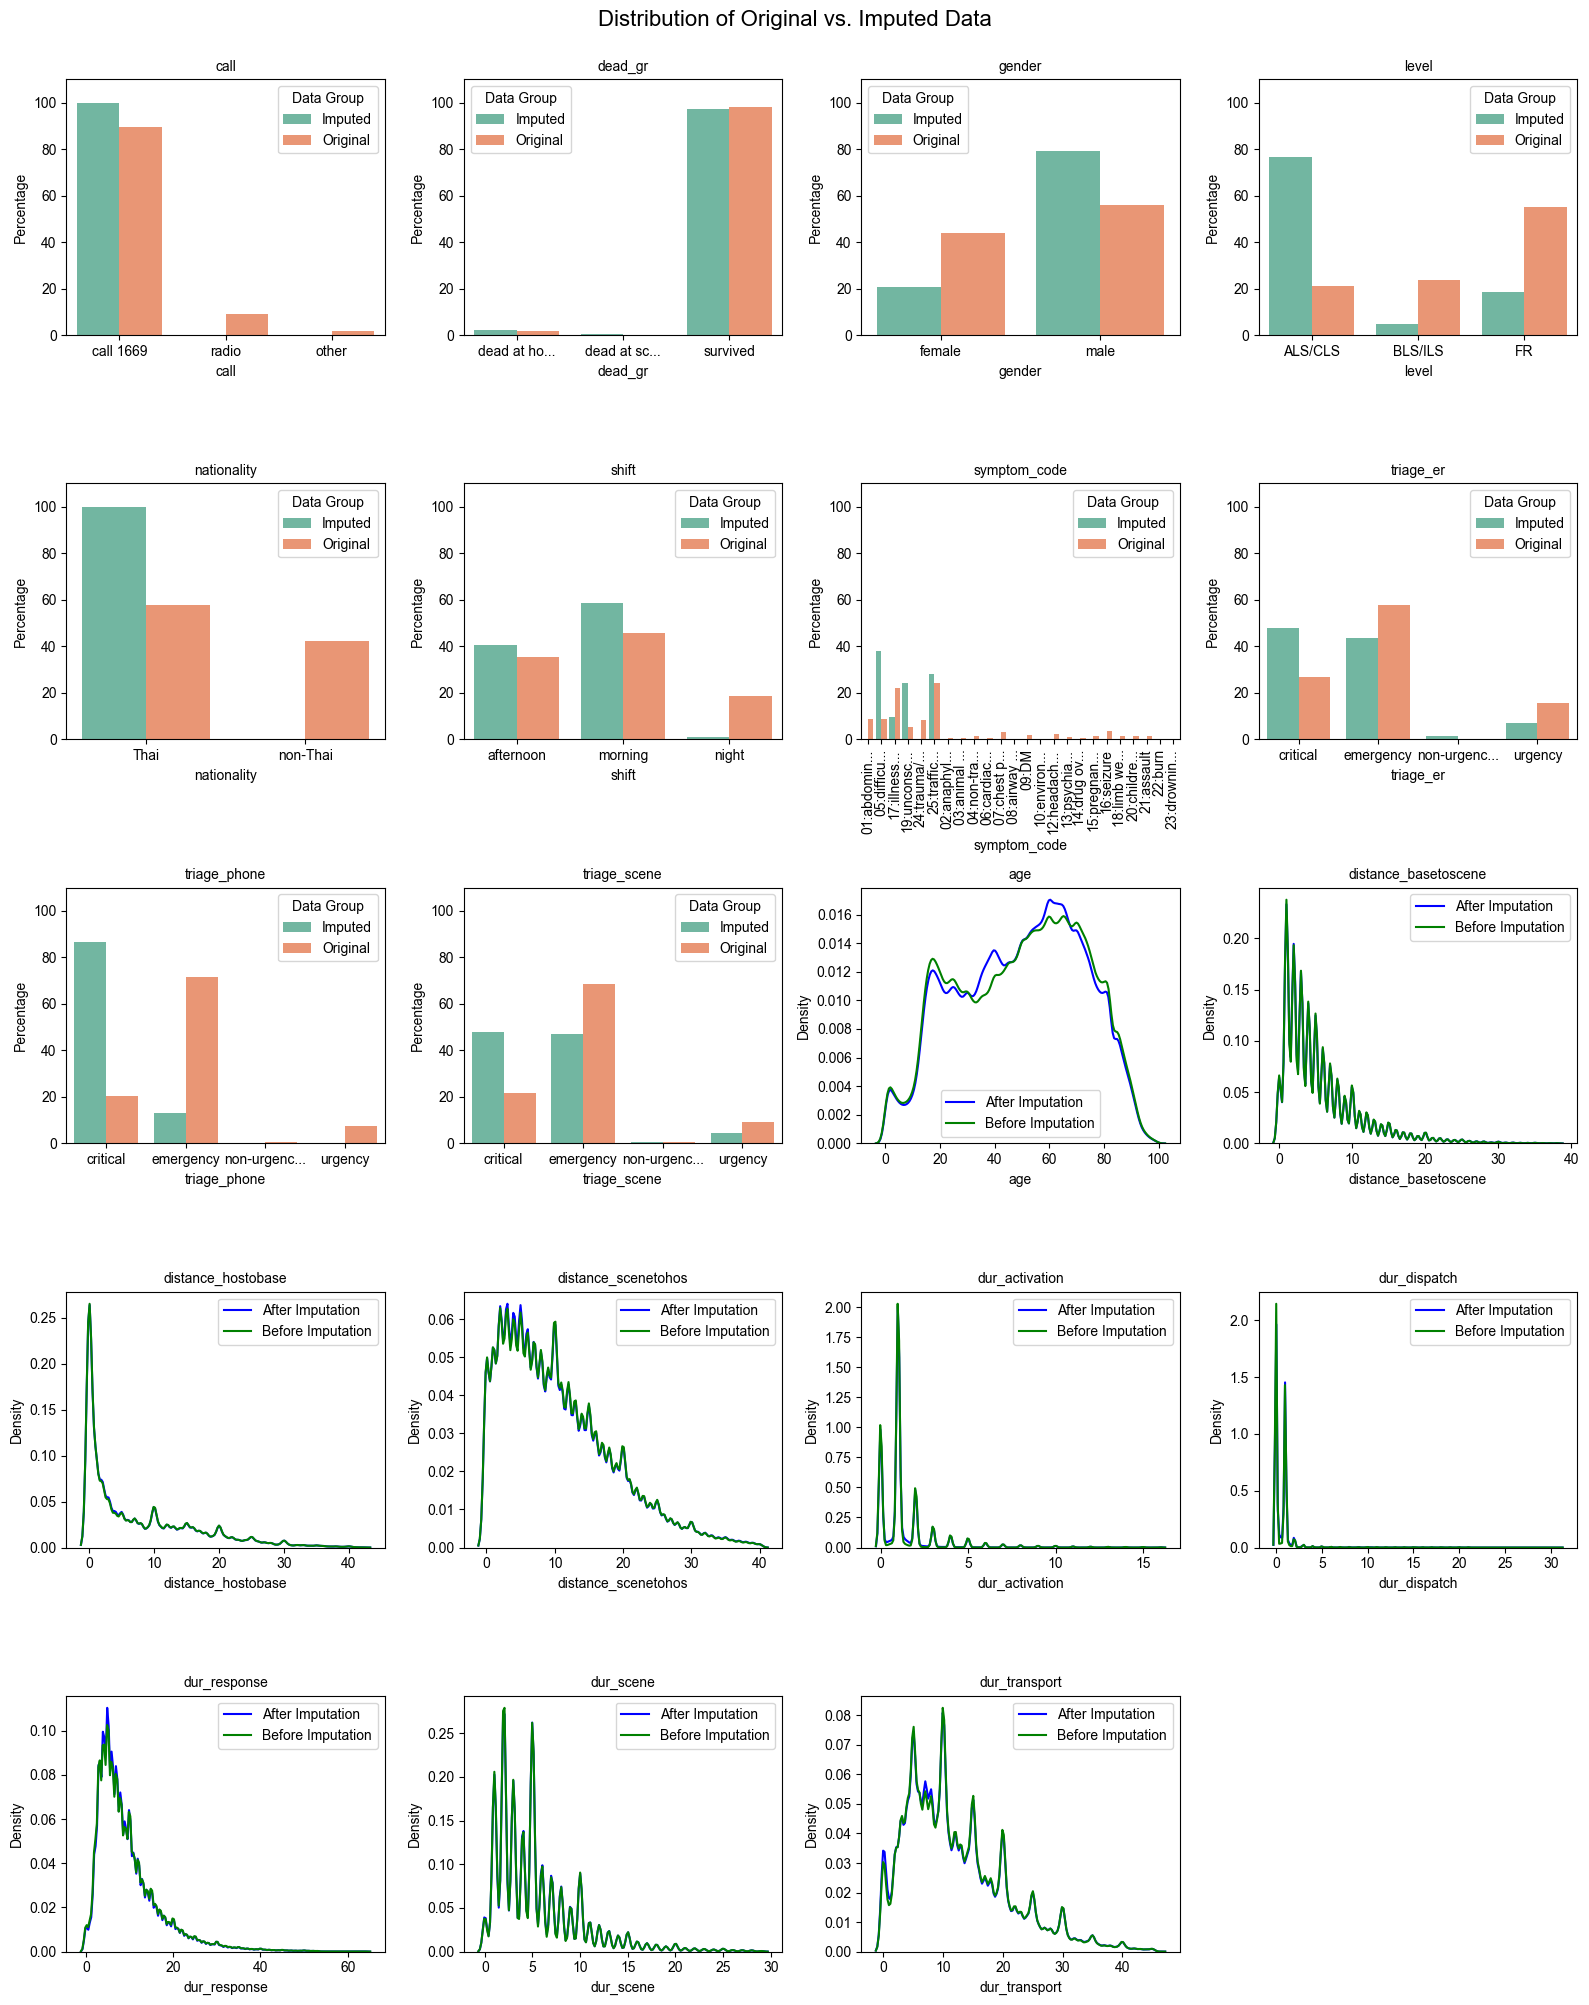

In [43]:
import math

# Set variables
all_vars = ['call', 'date', 'dead_gr', 'gender', 'level', 'nationality', 'prov', 'shift', 'symptom_code', 'triage_er', 'triage_phone', 'triage_scene', 'type', 'age', 'distance_basetoscene', 'distance_hostobase', 'distance_scenetohos', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'dur_transport']

df_forimpute = pd.read_csv('output/clean/ITEMS_forimpute.csv')
df_imputed = pd.read_csv('output/clean/ITEMS_imputed.csv')
display(df_forimpute.head())
display(df_imputed.head())

continuous_vars = [col for col in all_vars if df_forimpute[col].dtype in ['int64', 'float64']]
categorical_vars = [col for col in all_vars if col not in continuous_vars]

plt.rcParams['font.family'] = 'Arial'

# Count the number of variables with missing values
vars_with_missing = [var for var in all_vars if df_forimpute[var].isnull().sum() > 0]
num_vars = len(vars_with_missing)

# Limit columns to 4
columns = 4
rows = math.ceil(num_vars / columns)

# Create subplots
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()

# Add a big title for the entire plot
fig.suptitle("Distribution of Original vs. Imputed Data", fontsize=16, y=1.0)

# Iterate through variables with missing values
for i, var in enumerate(vars_with_missing):
    ax = axes[i]

    if var in continuous_vars:
        sns.kdeplot(df_imputed[var].dropna(), label='After Imputation', color='blue', ax=ax)
        sns.kdeplot(df_forimpute[var].dropna(), label='Before Imputation', color='green', ax=ax)
        ax.set_title(var, fontsize=10)
        ax.legend()

    elif var in categorical_vars:
        df_forvisualize = df_imputed.copy()
        df_forvisualize['Imputed'] = 'Original'
        df_forvisualize.loc[df_forimpute[var].isnull(), 'Imputed'] = 'Imputed'

        count_data = (
            df_forvisualize.groupby(['Imputed', var])
            .size()
            .reset_index(name='Count')
        )

        total_counts = count_data.groupby('Imputed')['Count'].transform('sum')
        count_data['Percentage'] = (count_data['Count'] / total_counts) * 100
        count_data[var] = count_data[var].apply(lambda x: f'{x[:10]}...' if len(str(x)) > 10 else x)

        sns.barplot(x=var, y='Percentage', hue='Imputed', data=count_data, palette="Set2", ax=ax)
        ax.set_title(var, fontsize=10)
        ax.set_xlabel(var)
        ax.set_ylim(top=110)
        ax.legend(title="Data Group")

        if len(df_imputed[var].unique()) > 5:
            ax.tick_params(axis='x', rotation=90)

# Hide unused subplots
for j in range(len(vars_with_missing), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ks_2samp, chi2_contingency

# Ensure both dataframes have the same structure
df_forimpute = pd.read_csv('output/clean/ITEMS_forimpute.csv')
df_imputed = pd.read_csv('output/clean/ITEMS_imputed_RF.csv')

assert df_forimpute.shape == df_imputed.shape, "Dataframe shapes do not match"
assert all(df_forimpute.columns == df_imputed.columns), "Column names do not match"

# Identify numerical and categorical variables
numerical_vars = df_forimpute.select_dtypes(include=['number']).columns
categorical_vars = df_forimpute.select_dtypes(include=['object', 'category']).columns

### 1. Distribution Comparison

print("\n--- Effect Size for Numerical Variables ---")
for col in numerical_vars:
    observed = df_forimpute[col].dropna()
    imputed = df_imputed[col]

    # Kolmogorov-Smirnov Test (Use D-statistic, not p-value)
    ks_stat, _ = ks_2samp(observed.sample(50000, random_state=42),  # Use sample to speed up
                          imputed.sample(50000, random_state=42))  # KS test effect size

    # Standardized Mean Difference (Cohen’s d)
    mean_diff = abs(observed.mean() - imputed.mean())
    pooled_std = np.sqrt((observed.std()**2 + imputed.std()**2) / 2)
    smd = mean_diff / pooled_std  # Cohen's d

    print(f"{col}: KS D-stat = {ks_stat:.2f}, Cohen's d = {smd:.2f}")

print("\n--- Effect Size for Categorical Variables ---")
for col in categorical_vars:
    observed_counts = df_forimpute[col].dropna().value_counts().values
    imputed_counts = df_imputed[col].value_counts().values

    if len(observed_counts) == len(imputed_counts):  # Ensure same categories
        chi2_stat, _, _, _ = chi2_contingency([observed_counts, imputed_counts])

        # Compute Cramér’s V effect size
        n = sum(observed_counts)
        cramers_v = np.sqrt(chi2_stat / (n * (min(len(observed_counts), len(imputed_counts)) - 1)))

        print(f"{col}: Cramér’s V = {cramers_v:.2f}")
    else:
        print(f"{col}: Skipped (category mismatch between observed and imputed)")

,Unnamed: 0,date,shift,call,symptom_code,triage_phone,type,level,distance_basetoscene,distance_scenetohos,distance_hostobase,triage_scene,gender,age,nationality,triage_er,prov,dur_dispatch,dur_activation,dur_response,dur_scene,dur_transport,dur_prehos,dispatch,activation,response,dead,source,dead_gr,missing
0,0,2021-10-16,afternoon,call 1669,25:traffic injury,emergency,land,BLS/ILS,4.0,4.0,4.0,emergency,male,46.0,Thai,critical,ลำพูน,1.0,2.0,5.0,7.0,4.0,16.0,<= 1 min,<= 2 min,<= 8,survived,ITEMS,survived,False
1,1,2021-10-15,morning,call 1669,17:illness/fatigue,emergency,land,FR,4.0,5.0,3.0,emergency,female,37.0,Thai,urgency,ปัตตานี,1.0,1.0,7.0,10.0,5.0,22.0,<= 1 min,<= 2 min,<= 8,survived,ITEMS,survived,False
2,2,2022-11-23,night,call 1669,21:assault,urgency,land,FR,21.0,14.0,1.0,urgency,male,33.0,Thai,urgency,ศรีสะเกษ,0.0,1.0,18.0,8.0,14.0,40.0,<= 1 min,<= 2 min,> 8,survived,ITEMS,survived,False
3,3,2021-10-15,morning,other,05:difficult breathing,emergency,land,ALS/CLS,6.0,5.0,0.0,emergency,female,66.0,Thai,emergency,ปัตตานี,5.0,15.0,27.0,8.0,5.0,40.0,> 1 min,> 2 min,> 8,survived,ITEMS,survived,False
4,4,2021-10-11,afternoon,call 1669,25:traffic injury,emergency,land,FR,4.0,15.0,0.0,emergency,female,18.0,Thai,emergency,สมุทรปราการ,0.0,0.0,11.0,6.0,26.0,43.0,<= 1 min,<= 2 min,> 8,survived,ITEMS,survived,False


,Unnamed: 0,date,shift,call,symptom_code,triage_phone,type,level,distance_basetoscene,distance_scenetohos,distance_hostobase,triage_scene,gender,age,nationality,triage_er,prov,dur_dispatch,dur_activation,dur_response,dur_scene,dur_transport,dur_prehos,dispatch,activation,response,dead,source,dead_gr,missing
0,0,202110,afternoon,call 1669,25:traffic injury,emergency,land,BLS/ILS,4.0,4.0,4.0,emergency,male,46.0,Thai,critical,ลำพูน,1.0,2.0,5.0,7.0,4.0,16.0,<= 1 min,<= 2 min,<= 8,survived,ITEMS,survived,False
1,1,202110,morning,call 1669,17:illness/fatigue,emergency,land,FR,4.0,5.0,3.0,emergency,female,37.0,Thai,urgency,ปัตตานี,1.0,1.0,7.0,10.0,5.0,22.0,<= 1 min,<= 2 min,<= 8,survived,ITEMS,survived,False
2,2,202211,night,call 1669,21:assault,urgency,land,FR,21.0,14.0,1.0,urgency,male,33.0,Thai,urgency,ศรีสะเกษ,0.0,1.0,18.0,8.0,14.0,40.0,<= 1 min,<= 2 min,> 8,survived,ITEMS,survived,False
3,3,202110,morning,other,05:difficult breathing,emergency,land,ALS/CLS,6.0,5.0,0.0,emergency,female,66.0,Thai,emergency,ปัตตานี,5.0,15.0,27.0,8.0,5.0,40.0,> 1 min,> 2 min,> 8,survived,ITEMS,survived,False
4,4,202110,afternoon,call 1669,25:traffic injury,emergency,land,FR,4.0,15.0,0.0,emergency,female,18.0,Thai,emergency,สมุทรปราการ,0.0,0.0,11.0,6.0,26.0,43.0,<= 1 min,<= 2 min,> 8,survived,ITEMS,survived,False



--- Effect Size for Numerical Variables ---
Unnamed: 0: KS D-stat = 0.00, Cohen's d = 0.00
distance_basetoscene: KS D-stat = 0.01, Cohen's d = 0.00
distance_scenetohos: KS D-stat = 0.00, Cohen's d = 0.01
distance_hostobase: KS D-stat = 0.01, Cohen's d = 0.00
age: KS D-stat = 0.02, Cohen's d = 0.00
dur_dispatch: KS D-stat = 0.05, Cohen's d = 0.01
dur_activation: KS D-stat = 0.03, Cohen's d = 0.01
dur_response: KS D-stat = 0.02, Cohen's d = 0.01
dur_scene: KS D-stat = 0.01, Cohen's d = 0.00
dur_transport: KS D-stat = 0.01, Cohen's d = 0.01
dur_prehos: KS D-stat = nan, Cohen's d = 0.00

--- Effect Size for Categorical Variables ---
date: Skipped (category mismatch between observed and imputed)
shift: Cramér’s V = 0.00
call: Cramér’s V = 0.00
symptom_code: Cramér’s V = 0.00
triage_phone: Cramér’s V = 0.00
type: Cramér’s V = 0.00
level: Cramér’s V = 0.00
triage_scene: Cramér’s V = 0.01
gender: Cramér’s V = 0.04
nationality: Cramér’s V = 0.06
triage_er: Cramér’s V = 0.03
prov: Cramér’s V = 

visualization will be conducted on *Tableau software*

# 3.Analyse
-------------------------------

In [2]:
file_name = 'ITEMS_imputed_RF'
data_dir = 'output/clean'
output_dir = 'output/clean'

df, _, _ = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

prov_transfer = ['แพร่', 'ลำพูน', 'มหาสารคาม', 'สุพรรณบุรี', 'สระแก้ว', 'พัทลุง', 'ชุมพร', 'สงขลา'] #tranfers at least one year before October 2021
prov_transfer_compare = ['แพร่', 'ลำพูน', 'มหาสารคาม', 'สุพรรณบุรี', 'สระแก้ว', 'พัทลุง', 'ชุมพร'] #tranfers at least one year before October 2021
prov_nontransfer_compare = ['น่าน', 'พะเยา', 'กาฬสินธุ์', 'ราชบุรี', 'จันทบุรี', 'ยะลา', 'กระบี่'] #compare provinces
df['transfer'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer else 'no')
df['transfer_compare'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer_compare else 'no' if x in prov_nontransfer_compare else None)

trauma = ['03:animal bite', '10:environmental injury', '21:assault', '22:burn', '23:drowning', '24:trauma/fall', '25:traffic injury']
df['trauma'] = df['symptom_code'].apply(lambda x: 'cardiac arrest' if x == '06:cardiac arrest' else 'trauma' if x in trauma else 'non-trauma' if pd.notna(x) else None)

df['response_10km'] = df.apply(
    lambda row: '<= 8' if (row['dur_response'] <= 8 and row['distance_basetoscene'] <= 10) else
                '> 8' if (row['dur_response'] > 8 and row['distance_basetoscene'] <= 10) else
                None, axis=1
)

# Define the triage levels with their corresponding priority
triage_priority = {'critical': 1, 'emergency': 2, 'urgency': 3, 'non-urgency': 4}

# Lambda function to categorize the triage
df['perform_scene'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_scene']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_scene']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and row['triage_phone'] == row['triage_scene']
        else None
    ),
    axis=1
)
df['perform_er'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_er']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_er']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and row['triage_phone'] == row['triage_er']
        else None
    ),
    axis=1
)
df['perform_er-scene'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and triage_priority[row['triage_scene']] > triage_priority[row['triage_er']]
        else 'over-triage' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and triage_priority[row['triage_scene']] < triage_priority[row['triage_er']]
        else 'accurate' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and row['triage_scene'] == row['triage_er']
        else None
    ),
    axis=1
)
df['ALS_BLS_access'] = df.apply(
    lambda row: (
        'access' if pd.notna(row['level']) and pd.notna(row['triage_phone']) and row['level'] in ['ALS/CLS','BLS/ILS'] and row['triage_phone'] in ['critical', 'emergency']
        else 'non-access' if pd.notna(row['level']) and pd.notna(row['triage_phone']) and row['level'] not in ['ALS/CLS','BLS/ILS'] and row['triage_phone'] in ['critical', 'emergency']
        else None
    ),
    axis=1
)

df['gr_triage_phone'] = df['triage_phone'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_scene'] = df['triage_scene'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_er'] = df['triage_er'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['hregion'] = df['prov']
process.DataManipulation.mapping(df, 'hregion')

# Grouping the performance / Any from imputation
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8 min' if pd.notna(x) and x <= 8 else
    '> 8 min' if pd.notna(x) and x > 8 else
    None
)

df['dead'] = df.apply(
    lambda row: ('dead' if row['dead_gr'] in ['dead at hos', 'dead at scene'] else 'survived'), axis=1)

df_imputed = df.copy()
display(df_imputed.head())

File name                : ITEMS_imputed_RF
Path to data dictionary  : output/clean/data_dict-ITEMS_imputed_RF.xlsx
Path to cleaned dataset  : None


,Unnamed: 0,monthyear,shift,call,symptom_code,triage_phone,type,level,distance_basetoscene,distance_scenetohos,distance_hostobase,triage_scene,gender,age,nationality,triage_er,prov,dur_dispatch,dur_activation,dur_response,dur_scene,dur_transport,dur_prehos,dispatch,activation,response,dead,source,dead_gr,missing,transfer,transfer_compare,trauma,response_10km,perform_scene,perform_er,perform_er-scene,ALS_BLS_access,gr_triage_phone,gr_triage_scene,gr_triage_er,hregion
0,0,202110,afternoon,call 1669,25:traffic injury,emergency,land,BLS/ILS,4.0,4.0,4.0,emergency,male,46.0,Thai,critical,ลำพูน,1.0,2.0,5.0,7.0,4.0,16.0,<= 1 min,<= 2 min,<= 8 min,survived,ITEMS,survived,False,yes,yes,trauma,<= 8,accurate,under-triage,under-triage,access,emergency,emergency,critical,เขตสุขภาพที่ 1
1,1,202110,morning,call 1669,17:illness/fatigue,emergency,land,FR,4.0,5.0,3.0,emergency,female,37.0,Thai,urgency,ปัตตานี,1.0,1.0,7.0,10.0,5.0,22.0,<= 1 min,<= 2 min,<= 8 min,survived,ITEMS,survived,False,no,None,non-trauma,<= 8,accurate,over-triage,over-triage,non-access,emergency,emergency,non-emergent,เขตสุขภาพที่ 12
2,2,202211,night,call 1669,21:assault,urgency,land,FR,21.0,14.0,1.0,urgency,male,33.0,Thai,urgency,ศรีสะเกษ,0.0,1.0,18.0,8.0,14.0,40.0,<= 1 min,<= 2 min,> 8 min,survived,ITEMS,survived,False,no,None,trauma,None,accurate,accurate,accurate,None,non-emergent,non-emergent,non-emergent,เขตสุขภาพที่ 10
3,3,202110,morning,other,05:difficult breathing,emergency,land,ALS/CLS,6.0,5.0,0.0,emergency,female,66.0,Thai,emergency,ปัตตานี,5.0,15.0,27.0,8.0,5.0,40.0,> 1 min,> 2 min,> 8 min,survived,ITEMS,survived,False,no,None,non-trauma,> 8,accurate,accurate,accurate,access,emergency,emergency,emergency,เขตสุขภาพที่ 12
4,4,202110,afternoon,call 1669,25:traffic injury,emergency,land,FR,4.0,15.0,0.0,emergency,female,18.0,Thai,emergency,สมุทรปราการ,0.0,0.0,11.0,6.0,26.0,43.0,<= 1 min,<= 2 min,> 8 min,survived,ITEMS,survived,False,no,None,trauma,> 8,accurate,accurate,accurate,non-access,emergency,emergency,emergency,เขตสุขภาพที่ 6


In [3]:
file_name = 'ITEMS_forimpute'
data_dir = 'output/clean'
output_dir = 'output/clean'

df, _, _ = process.DataCleaning.clean(file_name, data_dir, output_dir, clear=True, export_df=False)

prov_transfer = ['แพร่', 'ลำพูน', 'มหาสารคาม', 'สุพรรณบุรี', 'สระแก้ว', 'พัทลุง', 'ชุมพร', 'สงขลา'] #tranfers at least one year before October 2021
prov_transfer_compare = ['แพร่', 'ลำพูน', 'มหาสารคาม', 'สุพรรณบุรี', 'สระแก้ว', 'พัทลุง', 'ชุมพร'] #tranfers at least one year before October 2021
prov_nontransfer_compare = ['น่าน', 'พะเยา', 'กาฬสินธุ์', 'ราชบุรี', 'จันทบุรี', 'ยะลา', 'กระบี่'] #compare provinces
df['transfer'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer else 'no')
df['transfer_compare'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer_compare else 'no' if x in prov_nontransfer_compare else None)

trauma = ['03:animal bite', '10:environmental injury', '21:assault', '22:burn', '23:drowning', '24:trauma/fall', '25:traffic injury']
df['trauma'] = df['symptom_code'].apply(lambda x: 'cardiac arrest' if x == '06:cardiac arrest' else 'trauma' if x in trauma else 'non-trauma' if pd.notna(x) else None)

df['response_10km'] = df.apply(
    lambda row: '<= 8' if (row['dur_response'] <= 8 and row['distance_basetoscene'] <= 10) else
                '> 8' if (row['dur_response'] > 8 and row['distance_basetoscene'] <= 10) else
                None, axis=1
)

# Define the triage levels with their corresponding priority
triage_priority = {'critical': 1, 'emergency': 2, 'urgency': 3, 'non-urgency': 4}

# Lambda function to categorize the triage
df['perform_scene'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_scene']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_scene']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and row['triage_phone'] == row['triage_scene']
        else None
    ),
    axis=1
)
df['perform_er'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_er']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_er']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and row['triage_phone'] == row['triage_er']
        else None
    ),
    axis=1
)
df['perform_er-scene'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and triage_priority[row['triage_scene']] > triage_priority[row['triage_er']]
        else 'over-triage' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and triage_priority[row['triage_scene']] < triage_priority[row['triage_er']]
        else 'accurate' if pd.notna(row['triage_scene']) and pd.notna(row['triage_er']) and row['triage_scene'] == row['triage_er']
        else None
    ),
    axis=1
)
df['ALS_access'] = df.apply(
    lambda row: (
        'access' if pd.notna(row['level']) and pd.notna(row['triage_phone']) and row['level'] == 'ALS/CLS' and row['triage_phone'] in ['critical', 'emergency']
        else 'non-access' if pd.notna(row['level']) and pd.notna(row['triage_phone']) and row['level'] != 'ALS/CLS' and row['triage_phone'] in ['critical', 'emergency']
        else None
    ),
    axis=1
)

df['gr_triage_phone'] = df['triage_phone'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_scene'] = df['triage_scene'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['gr_triage_er'] = df['triage_er'].apply(
    lambda x: 'non-emergent' if x in ['urgency', 'non-urgency'] else x
)

df['hregion'] = df['prov']
process.DataManipulation.mapping(df, 'hregion')

# Grouping the performance / Any from imputation
df['dispatch'] = df['dur_dispatch'].apply(
    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
    '> 1 min' if pd.notna(x) and x > 1 else
    None
)
df['activation'] = df['dur_activation'].apply(
    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
    '> 2 min' if pd.notna(x) and x > 2 else
    None
)
df['response'] = df['dur_response'].apply(
    lambda x: '<= 8 min' if pd.notna(x) and x <= 8 else
    '> 8 min' if pd.notna(x) and x > 8 else
    None
)

df['dead'] = df.apply(
    lambda row: ('dead' if row['dead_gr'] in ['dead at hos', 'dead at scene'] else 'survived'), axis=1)

df_forimpute = df.copy()
display(df_forimpute.head())

File name                : ITEMS_forimpute
Path to data dictionary  : output/clean/data_dict-ITEMS_forimpute.xlsx
Path to cleaned dataset  : None


,Unnamed: 0,date,shift,call,symptom_code,triage_phone,type,level,distance_basetoscene,distance_scenetohos,distance_hostobase,triage_scene,gender,age,nationality,triage_er,prov,dur_dispatch,dur_activation,dur_response,dur_scene,dur_transport,dur_prehos,dispatch,activation,response,dead,source,dead_gr,missing,transfer,transfer_compare,trauma,response_10km,perform_scene,perform_er,perform_er-scene,ALS_access,gr_triage_phone,gr_triage_scene,gr_triage_er,hregion
0,0,2021-10-16,afternoon,call 1669,25:traffic injury,emergency,land,BLS/ILS,4.0,4.0,4.0,emergency,male,46.0,Thai,critical,ลำพูน,1.0,2.0,5.0,7.0,4.0,16.0,<= 1 min,<= 2 min,<= 8 min,survived,ITEMS,survived,False,yes,yes,trauma,<= 8,accurate,under-triage,under-triage,non-access,emergency,emergency,critical,เขตสุขภาพที่ 1
1,1,2021-10-15,morning,call 1669,17:illness/fatigue,emergency,land,FR,4.0,5.0,3.0,emergency,female,37.0,Thai,urgency,ปัตตานี,1.0,1.0,7.0,10.0,5.0,22.0,<= 1 min,<= 2 min,<= 8 min,survived,ITEMS,survived,False,no,None,non-trauma,<= 8,accurate,over-triage,over-triage,non-access,emergency,emergency,non-emergent,เขตสุขภาพที่ 12
2,2,2022-11-23,night,call 1669,21:assault,urgency,land,FR,21.0,14.0,1.0,urgency,male,33.0,Thai,urgency,ศรีสะเกษ,0.0,1.0,18.0,8.0,14.0,40.0,<= 1 min,<= 2 min,> 8 min,survived,ITEMS,survived,False,no,None,trauma,None,accurate,accurate,accurate,None,non-emergent,non-emergent,non-emergent,เขตสุขภาพที่ 10
3,3,2021-10-15,morning,other,05:difficult breathing,emergency,land,ALS/CLS,6.0,5.0,0.0,emergency,female,66.0,Thai,emergency,ปัตตานี,5.0,15.0,27.0,8.0,5.0,40.0,> 1 min,> 2 min,> 8 min,survived,ITEMS,survived,False,no,None,non-trauma,> 8,accurate,accurate,accurate,access,emergency,emergency,emergency,เขตสุขภาพที่ 12
4,4,2021-10-11,afternoon,call 1669,25:traffic injury,emergency,land,FR,4.0,15.0,0.0,emergency,female,18.0,Thai,emergency,สมุทรปราการ,0.0,0.0,11.0,6.0,26.0,43.0,<= 1 min,<= 2 min,> 8 min,survived,ITEMS,survived,False,no,None,trauma,> 8,accurate,accurate,accurate,non-access,emergency,emergency,emergency,เขตสุขภาพที่ 6


In [61]:
# Ensure 'monthyear' is treated as a string for grouping
df_imputed['monthyear'] = df_imputed['monthyear'].astype(str)

# Count the number of cases per month per province
cases_per_month = df_imputed.groupby(['prov', 'monthyear']).size().reset_index(name='case_count')

overall_stats = cases_per_month['case_count'].agg(
    median_cases='median',  # P50 (Median)
    p25_cases=lambda x: x.quantile(0.25),
    p75_cases=lambda x: x.quantile(0.75)
)

# Compute the average number of cases per month for each province
avg_cases_per_province = cases_per_month.groupby('prov')['case_count'].agg(
    avg_cases_per_month='median',  # P50 (Median)
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()
avg_cases_per_province['transfer'] = avg_cases_per_province['prov'].apply(lambda x:'yes' if x in prov_transfer else 'no')

# Compute the median, P25, and P75 per group
avg_cases_per_group = avg_cases_per_province.groupby('transfer').agg(
    median_cases=('avg_cases_per_month', 'median'),
    p25_cases=('avg_cases_per_month', lambda x: x.quantile(0.25)),
    p75_cases=('avg_cases_per_month', lambda x: x.quantile(0.75))
).reset_index()

display(overall_stats)
display(avg_cases_per_group)

median_cases    1579.0
p25_cases       1078.0
p75_cases       2580.0
Name: case_count, dtype: float64

,transfer,median_cases,p25_cases,p75_cases
0,no,1611.5,1067.000,2558.750
1,yes,1374.0,1312.375,2019.625


In [5]:
group_by = 'transfer'
df = df_imputed.copy()

table_name = '01_characteristics'
parameters = ['gender', 'age', 'nationality', 'shift', 'call', 'trauma', 'triage_phone', 'triage_scene', 'triage_er']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=True)

table_name = '02_performance'
parameters = ['level', 'ALS_BLS_access', 'perform_scene', 'perform_er', 'dur_dispatch', 'dur_activation', 'dur_response', 'dur_scene', 'dur_transport', 'dur_prehos', 'dead_gr']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=True)

table_name = '03_mortality'
parameters = ['level', 'dead_gr']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=False)
analyse.Descriptive.describe(df[df['triage_er'].isin(['critical'])], parameters, group_by, overall=True, table_name=f'{table_name}-Critical', export_result=False)
analyse.Descriptive.describe(df[df['triage_er'].isin(['emergency'])], parameters, group_by, overall=True, table_name=f'{table_name}-Emergency', export_result=False)
analyse.Descriptive.describe(df[(df['symptom_code'].isin(['06:cardiac arrest']))], parameters, group_by, overall=True, table_name=f'{table_name}-Cardiac Arrest', export_result=False)
analyse.Descriptive.describe(df[(df['triage_er'].isin(['critical'])) & (df['symptom_code'].isin(['06:cardiac arrest']))], parameters, group_by, overall=True, table_name=f'{table_name}-Cardiac Arrest (Critical)', export_result=False)
analyse.Descriptive.describe(df[df['triage_er'].isin(['urgency', 'non-urgency'])], parameters, group_by, overall=True, table_name=f'{table_name}-Non-emergency', export_result=False)

01_characteristics
Analysis of age using Mann-Whitney U Test
Characteristics    Total          yes            no             P-value    Effect Size    Interpretation
-----------------  -------------  -------------  -------------  ---------  -------------  ----------------
gender                                                          0.00       0.01           Negligible
female             1,402,626      132,376        1,270,250
                   (41.49%)       (41.93%)       (41.45%)
male               1,977,759      183,304        1,794,455
                   (58.51%)       (58.07%)       (58.55%)
age                52.00          53.00          51.61          0.00       0.03           Negligible
                   (32.00-67.00)  (34.00-68.00)  (32.00-67.00)
nationality                                                     0.00       0.01           Negligible
Thai               2,084,935      203,000        1,881,935
                   (61.68%)       (64.31%)       (61.41%)
non-Thai  

In [ ]:
outcome = 'dead'
predictors = ['transfer', 'gender', 'age', 'nationality', 'shift', 'call', 'symptom_code', 'perform_scene', 'perform_er', 'level', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'dur_transport', 'distance_basetoscene', 'hregion']
df = df_imputed[(df_imputed['symptom_code'] == '06:cardiac arrest')].copy()
df_sens = df_forimpute[(df_imputed['symptom_code'] == '06:cardiac arrest')].copy()

# Compute Variance Inflation Factor (VIF)
df_logis = df[[outcome] + predictors]
categorical_vars = ['transfer', 'gender', 'nationality', 'shift', 'call', 'symptom_code', 'level', 'perform_scene', 'perform_er', 'hregion']
df_dummy = pd.get_dummies(df_logis, columns=categorical_vars, drop_first=True)

# Prepare feature matrix
import statsmodels.api as sm
X = df_dummy.drop(columns=[outcome]).dropna()
X = X.astype(float)
X = sm.add_constant(X)  # Add constant for VIF computation

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print("Variance Inflation Factor (VIF) Results:")
print(vif_data)

reference_group = {
    'gender': 'male',
    'nationality': 'Thai',
    'shift': 'morning',
    'call': 'call 1669',
    'trauma': 'cardiac arrest',
    'triage_scene': 'urgency',
    'triage_er': 'urgency',
    'gr_triage_phone': 'non-emergent',
    'gr_triage_scene': 'non-emergent',
    'gr_triage_er': 'non-emergent',
    'level': 'FR',
    'perform_scene': 'accurate',
    'perform_er': 'accurate',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
    'response': '<= 8 min',
    'transfer': 'no',
    'hregion': 'เขตสุขภาพที่ 1',
    'symptom_code': '06:cardiac arrest',
}

print('Logistic Rogression for Overall Patients')
df = df_imputed[(df_imputed['symptom_code'] == '06:cardiac arrest')]
predictors = ['transfer', 'gender', 'age', 'nationality', 'shift', 'call', 'perform_scene', 'perform_er', 'level', 'dur_activation', 'dur_dispatch', 'dur_response', 'dur_scene', 'dur_transport', 'distance_basetoscene', 'hregion']
analyse.Regression.binary_logistic(df, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead', export_result=True, table_name='03_LogisticRegression_univariate')
predictors = ['transfer', 'shift', 'perform_scene', 'perform_er', 'level', 'dur_activation', 'dur_response', 'dur_transport', 'distance_basetoscene', 'hregion']
analyse.Regression.binary_logistic(df, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead', export_result=True, table_name='03_LogisticRegression_multivariate')
analyse.Regression.binary_logistic(df_sens, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead')

Variance Inflation Factor (VIF) Results:
                       Feature        VIF
0                        const  39.445583
1                          age   1.055220
2               dur_activation   1.332503
3                 dur_dispatch   1.220486
4                 dur_response   2.681499
5                    dur_scene   1.088753
6                dur_transport   1.430440
7         distance_basetoscene   2.405810
8                 transfer_yes   1.366968
9                  gender_male   1.045134
10        nationality_non-Thai   1.023348
11               shift_morning   1.266912
12                 shift_night   1.278413
13                  call_other   1.011161
14                  call_radio   1.023266
15               level_BLS/ILS   1.123920
16                    level_FR   1.157242
17   perform_scene_over-triage   1.338259
18  perform_scene_under-triage   1.485786
19      perform_er_over-triage   1.301390
20     perform_er_under-triage   1.486946
21     hregion_เขตสุขภาพที่ 10   1.

In [19]:
print(df_imputed['symptom_code'].unique())

['25:traffic injury' '17:illness/fatigue' '21:assault'
 '05:difficult breathing' '16:seizure' '03:animal bite'
 '20:children problems' '24:trauma/fall'
 '02:anaphylaxis/allergic reaction' '19:unconsciousness/syncope'
 '15:pregnancy/delivery' '07:chest pain/discomfort'
 '12:headache/neck pain' '06:cardiac arrest'
 '01:abdominal pain/back/pelvis and inguinal area' '09:DM'
 '04:non-traumatic bleeding'
 '18:limb weakness/dysarthria/facial droop/stroke' '23:drowning'
 '13:psychiatric problems' '08:airway aspiration'
 '10:environmental injury' '22:burn' '14:drug overdose/intoxication']


In [20]:
for cbd in ['06:cardiac arrest', '07:chest pain/discomfort', '18:limb weakness/dysarthria/facial droop/stroke', '25:traffic injury']:
    
    df = df_imputed[(df_imputed['symptom_code'] == cbd)].copy()

    predictors = ['transfer', 'shift', 'perform_scene', 'perform_er', 'level', 'dur_activation', 'dur_response', 'dur_transport', 'distance_basetoscene', 'hregion']
    analyse.Regression.binary_logistic(df, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead', export_result=True, table_name=f'03_LogisticRegression_{cbd[:2]}')

                           Logit Regression Results                           
Dep. Variable:                   dead   No. Observations:                15136
Model:                          Logit   Df Residuals:                    15111
Method:                           MLE   Df Model:                           24
Date:                Tue, 25 Mar 2025   Pseudo R-squ.:                  0.2123
Time:                        16:16:13   Log-Likelihood:                -7847.2
converged:                       True   LL-Null:                       -9962.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -0.8065      0.081    

In [28]:
outcome = 'dead'
predictors = ['gender', 'age', 'nationality', 'shift', 'call', 'perform_scene', 'perform_er', 'ALS_access', 'activation', 'dispatch', 'response', 'dur_scene', 'dur_transport', 'distance_basetoscene', 'transfer', 'prov']

# Compute Variance Inflation Factor (VIF)
df = df_imputed.dropna(subset='transfer')
df = df[df['gr_triage_er'].isin(['critical','emergency'])]
df_logis = df[[outcome] + predictors]
categorical_vars = ['gender', 'nationality', 'shift', 'call', 'perform_scene', 'perform_er',
                    'ALS_access', 'activation', 'dispatch', 'response', 'transfer', 'prov']
df_dummy = pd.get_dummies(df_logis, columns=categorical_vars, drop_first=True)

# Prepare feature matrix
import statsmodels.api as sm
X = df_dummy.drop(columns=[outcome]).dropna()
X = X.astype(float)
X = sm.add_constant(X)  # Add constant for VIF computation

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print("Variance Inflation Factor (VIF) Results:")
print(vif_data)

reference_group = {
    'gender': 'male',
    'nationality': 'Thai',
    'shift': 'morning',
    'call': 'call 1669',
    'trauma': 'cardiac arrest',
    'triage_scene': 'urgency',
    'triage_er': 'urgency',
    'gr_triage_phone': 'non-emergent',
    'gr_triage_scene': 'non-emergent',
    'gr_triage_er': 'non-emergent',
    'level': 'FR',
    'perform_scene': 'accurate',
    'perform_er': 'accurate',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
    'response': '<= 8',
    'transfer': 'no',
    'prov': 'เขตสุขภาพที่ 1',
    'symptom_code': '06:cardiac arrest',
}

analyse.Regression.binary_logistic(df_imputed.dropna(subset='transfer'), independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead', export_result=True, table_name='03_LogisticRegression')

# predictors = ['gender', 'age', 'nationality', 'shift', 'call', 'symptom_code', 'triage_phone',  'perform_scene', 'perform_er', 'level', 'activation', 'dispatch', 'response', 'dur_scene', 'dur_transport', 'distance_basetoscene', 'transfer', 'prov']
# analyse.Regression.binary_logistic(df_forimpute.dropna(), independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead')

Variance Inflation Factor (VIF) Results:
                       Feature        VIF
0                        const  24.014493
1                          age   1.039986
2                    dur_scene   1.162451
3                dur_transport   1.245272
4         distance_basetoscene   1.728612
5                  gender_male   1.015879
6         nationality_non-Thai   1.014838
7                shift_morning   1.262074
8                  shift_night   1.254991
9                   call_other   1.070775
10                  call_radio   1.060361
11   perform_scene_over-triage   1.181665
12  perform_scene_under-triage   1.325737
13      perform_er_over-triage   1.192605
14     perform_er_under-triage   1.331358
15       ALS_access_non-access   1.189264
16          activation_> 2 min   1.211879
17            dispatch_> 1 min   1.114734
18                response_> 8   1.729292
19                transfer_yes   1.137539
20        prov_เขตสุขภาพที่ 11   1.380416
21        prov_เขตสุขภาพที่ 12   1.

In [6]:
print(df_imputed['symptom_code'].unique())

['25:traffic injury' '17:illness/fatigue' '21:assault'
 '05:difficult breathing' '16:seizure' '03:animal bite'
 '20:children problems' '24:trauma/fall'
 '02:anaphylaxis/allergic reaction' '19:unconsciousness/syncope'
 '15:pregnancy/delivery' '07:chest pain/discomfort'
 '12:headache/neck pain' '06:cardiac arrest'
 '01:abdominal pain/back/pelvis and inguinal area' '09:DM'
 '04:non-traumatic bleeding'
 '18:limb weakness/dysarthria/facial droop/stroke' '23:drowning'
 '13:psychiatric problems' '08:airway aspiration'
 '10:environmental injury' '22:burn' '14:drug overdose/intoxication']


In [13]:
outcome = 'dead'
predictors = ['gender', 'age', 'nationality', 'shift', 'call', 'triage_phone', 'perform_scene', 'perform_er', 'level', 'activation', 'dispatch', 'response', 'dur_scene', 'dur_transport', 'distance_basetoscene', 'transfer', 'prov']

# # Compute Variance Inflation Factor (VIF)
# df_logis = df[[outcome] + predictors]
# categorical_vars = ['gender', 'nationality', 'shift', 'call', 'symptom_code', 'triage_phone', 'perform_scene', 'perform_er',
#                     'level', 'activation', 'dispatch', 'response', 'transfer']
# df_dummy = pd.get_dummies(df_logis, columns=categorical_vars, drop_first=True)

# # Prepare feature matrix
# import statsmodels.api as sm
# X = df_dummy.drop(columns=[outcome]).dropna()
# X = X.astype(float)
# X = sm.add_constant(X)  # Add constant for VIF computation

# from statsmodels.stats.outliers_influence import variance_inflation_factor
# vif_data = pd.DataFrame()
# vif_data["Feature"] = X.columns
# vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# # Display VIF values
# print("Variance Inflation Factor (VIF) Results:")
# print(vif_data)

reference_group = {
    'gender': 'male',
    'nationality': 'Thai',
    'shift': 'morning',
    'call': 'call 1669',
    'trauma': 'non-trauma',
    'symptom_code': '06:cardiac arrest',
    'triage_scene': 'urgency',
    'triage_er': 'urgency',
    'gr_triage_phone': 'non-emergent',
    'gr_triage_scene': 'non-emergent',
    'gr_triage_er': 'non-emergent',
    'level': 'FR',
    'perform_scene': 'accurate',
    'perform_er': 'accurate',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
    'response': '<= 8',
    'transfer': 'no'
}

for cbd in ['06:cardiac arrest']:
    df_sub = df_imputed[df_imputed['symptom_code'] == cbd]
    print(f'{cbd}--------------------')
    analyse.Regression.binary_logistic(df_sub, independent_var=predictors, dependent_var=outcome, independent_assign=reference_group, dependent_assign='dead', export_result=True, table_name=f'04_LogisticRegression_{cbd[:2]}')

06:cardiac arrest--------------------
                           Logit Regression Results                           
Dep. Variable:                   dead   No. Observations:                 7863
Model:                          Logit   Df Residuals:                     7830
Method:                           MLE   Df Model:                           32
Date:                Fri, 21 Mar 2025   Pseudo R-squ.:                 0.06790
Time:                        13:42:37   Log-Likelihood:                -4928.3
converged:                       True   LL-Null:                       -5287.3
Covariance Type:            nonrobust   LLR p-value:                2.091e-130
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     

# End

In [42]:
group_by = 'transfer'

table_name = 'Table 3'
parameters = ['triage_phone', 'triage_scene', 'triage_er', 'level']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=False)

dispatch = ['emergency', 'non-emergency']
for dis in dispatch:
    table_name = f'Table 4-{dis}'
    sub_df = df.copy()
    sub_df['triage_gr'] = sub_df['triage_phone'].apply(lambda x: 'emergency' if x in ['critical', 'emergency'] else 'non-emergency')
    sub_df = sub_df[sub_df['triage_gr'] == dis]
    parameters = ['level']
    analyse.Descriptive.describe(sub_df, parameters, group_by, overall=True, table_name=table_name, export_result=False)


Table 3
Characteristics    Total      yes       no         P-value    Effect Size    Interpretation
-----------------  ---------  --------  ---------  ---------  -------------  ----------------
triage_phone                                       0.00       0.08           Negligible
emergency          2,412,803  213,433   2,199,370
                   (71.38%)   (67.61%)  (71.76%)
urgency            253,328    11,081    242,247
                   (7.49%)    (3.51%)   (7.90%)
critical           694,016    89,931    604,085
                   (20.53%)   (28.49%)  (19.71%)
non-urgency        20,238     1,235     19,003
                   (0.60%)    (0.39%)   (0.62%)
triage_scene                                       0.00       0.07           Negligible
emergency          2,299,525  192,361   2,107,164
                   (68.03%)   (60.94%)  (68.76%)
urgency            303,060    23,342    279,718
                   (8.97%)    (7.39%)   (9.13%)
critical           754,449    98,458    655,991


In [ ]:
node_colors = {
    'triage_phone-critical': 'rgb(179,71,71)',
    'triage_phone-emergency': 'rgb(179,179,107)',
    'triage_phone-urgency': 'rgb(107,179,107)',
    'triage_phone-non-urgency': 'rgb(179,179,179)',
    
    'triage_scene-critical': 'rgb(179,71,71)',
    'triage_scene-emergency': 'rgb(179,179,107)',
    'triage_scene-urgency': 'rgb(107,179,107)',
    'triage_scene-non-urgency': 'rgb(179,179,179)',
    
    'triage_er-critical': 'rgb(179,71,71)',
    'triage_er-emergency': 'rgb(179,179,107)',
    'triage_er-urgency': 'rgb(107,179,107)',
    'triage_er-non-urgency': 'rgb(179,179,179)'
}

graph.sankey(
    df, ['triage_phone', 'triage_er'], value_column=None, 
    width=1690, height=748, 
    title='Triage Sankey-phone_ER',
    show_as_percent=True,
    show_labels=False,
    node_colors=node_colors)

transfer = ['yes', 'no']
for t in transfer:
    sub_df = df[df['transfer'] == t]
    graph.sankey(
        sub_df, ['triage_phone', 'triage_er'], value_column=None, 
        width=845, height=748, 
        title= f'Triage_Transfer-{t} Sankey-phone_ER',
        show_as_percent=True,
        show_labels=False,
        node_colors=node_colors)
    

In [ ]:
import seaborn as sns
import matplotlib.colors as mcolors

def calculate_percentage(df, level, triage_group, transfer_status):
    filtered_df = df[(df['transfer'] == transfer_status) & (df['triage_phone'] == triage_group)]
    level_count = filtered_df[filtered_df['level'] == level].shape[0]
    total_count = filtered_df.shape[0]
    percentage = (level_count / total_count) * 100 if total_count > 0 else 0
    return percentage

# Create a new DataFrame to store the calculated percentages
percentages = []
ordered_triage_groups = ['critical', 'emergency', 'urgency', 'non-urgency']

for level in ['ALS/CLS', 'BLS/ILS', 'FR']:
    for triage_group in ordered_triage_groups:
        for transfer_status in ['yes', 'no']:
            percentage = calculate_percentage(df, level, triage_group, transfer_status)
            percentages.append({
                'triage_phone': triage_group,
                'level': level,
                'transfer': transfer_status,
                'percentage': percentage
            })

percentage_df = pd.DataFrame(percentages)

# Adjust the colors for the transfer status to match the tone of triage_phone colors
colors = {
    'yes': mcolors.to_rgba((179/255, 71/255, 71/255), 0.7),  # Similar to critical tone
    'no': mcolors.to_rgba((107/255, 179/255, 179/255), 0.7)  # Similar to a pastel blue tone
}

# Plot the recalculated percentages for each triage_phone group in 1 row and 3 columns with the specified order, custom colors, no grid, and no borders
plt.figure(figsize=(22, 7.5))

# ALS/CLS subplot
ax1 = plt.subplot(1, 3, 1)
sns.barplot(data=percentage_df[percentage_df['level'] == 'ALS/CLS'], x='percentage', y='triage_phone', hue='transfer', palette=colors)
ax1.set_title('ALS/CLS')
ax1.set_xlabel('Percentage')
ax1.set_ylabel('Triage Phone')
ax1.set_xlim(0, 100)
ax1.grid(False)
sns.despine(ax=ax1)

# BLS/ILS subplot
ax2 = plt.subplot(1, 3, 2)
sns.barplot(data=percentage_df[percentage_df['level'] == 'BLS/ILS'], x='percentage', y='triage_phone', hue='transfer', palette=colors)
ax2.set_title('BLS/ILS')
ax2.set_xlabel('Percentage')
ax2.set_ylabel('Triage Phone')
ax2.set_xlim(0, 100)
ax2.grid(False)
sns.despine(ax=ax2)

# FR subplot
ax3 = plt.subplot(1, 3, 3)
sns.barplot(data=percentage_df[percentage_df['level'] == 'FR'], x='percentage', y='triage_phone', hue='transfer', palette=colors)
ax3.set_title('FR')
ax3.set_xlabel('Percentage')
ax3.set_ylabel('Triage Phone')
ax3.set_xlim(0, 100)
ax3.grid(False)
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()


In [44]:
group_by = 'transfer'

table_name = 'Table 4'
parameters = ['dur_dispatch', 'dur_activation', 'dur_response', 'dur_scene', 'dur_transport', 'dur_prehos', 'distance_basetoscene', 'distance_scenetohos']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=False)

table_name = 'Table 5'
parameters = ['dispatch', 'activation', 'response', 'response_10km']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=False)

table_name = 'Table 6'
parameters = ['perform_scene', 'perform_er', 'dead']
analyse.Descriptive.describe(df, parameters, group_by, overall=True, table_name=table_name, export_result=False)

Table 4
Characteristics       Total          yes            no               P-value    Effect Size  Interpretation
--------------------  -------------  -------------  -------------  ---------  -------------  ----------------
dur_dispatch          0.19           0.20           0.18                   0           0.02  Negligible
                      (0.00-1.00)    (0.00-1.00)    (0.00-1.00)
dur_activation        1.00           1.00           1.00                   0           0.18  Small
                      (0.73-1.51)    (1.00-2.00)    (0.57-1.33)
dur_response          7.50           8.00           7.25                   0           0.05  Negligible
                      (5.00-12.00)   (5.00-12.36)   (4.85-12.00)
dur_scene             4.14           5.00           4.00                   0           0.11  Small
                      (2.00-7.00)    (3.00-8.00)    (2.00-7.00)
dur_transport         10.00          10.00          10.00                  0           0.01  Negligible
       

In [ ]:
duration_columns = ['dur_dispatch', 'dur_activation', 'dur_response', 'dur_prehos']

# Melt the DataFrame to have a long format suitable for seaborn boxplot
melted_df = df[duration_columns + ['transfer']].melt(id_vars='transfer', var_name='Duration Type', value_name='Duration')

# Adjust the colors for the transfer status to match the tone of triage_phone colors
colors = {
    'yes': mcolors.to_rgba((179/255, 71/255, 71/255), 0.7),  # Similar to critical tone
    'no': mcolors.to_rgba((107/255, 179/255, 179/255), 0.7)  # Similar to a pastel blue tone
}

# Plot the box plot for the selected duration columns with hue by 'transfer'
plt.figure(figsize=(20, 9))
sns.boxplot(x='Duration Type', y='Duration', hue='transfer', data=melted_df, palette=colors, showfliers=False)
plt.title('Box Plot of Duration Types by Transfer')
plt.xlabel('Duration Type')
plt.ylabel('Duration')
plt.ylim(top=60)
plt.grid(False)
sns.despine()
plt.show()

In [ ]:
display(df['perform_er-scene'].value_counts())

In [ ]:
df_dead = df[(df['symptom_code'] == '06:cardiac arrest') & (df['triage_er'] == 'critical')].copy()
df_dead['age_gr'] = df_dead['age'].apply(lambda x: '> 60' if x > 60 else '<= 60')

predictors = [
    'transfer', #tranfers
    'age_gr', 'gender', 'nationality', 'shift', #demographic
    'call', 'level', 'perform_scene', 'perform_er-scene', 'dispatch', 'activation', 'response'
    ]

for p in predictors:
    analyse.describe(df_dead, ['dead'], p, overall=True, bootstrap=False, table_name=f'Table Dead-{p}')

In [ ]:
df_dead = df[(df['symptom_code'] == '06:cardiac arrest') & (df['triage_er'] == 'critical')].copy()
df_dead['age_gr'] = df_dead['age'].apply(lambda x: '> 60' if x > 60 else '<= 60')



outcome_column = 'dead'
outcome_choice = 'dead'  

predictors = [
    'transfer', #tranfers
    'gender', 'nationality', 'shift', #demographic
    'level', 'perform_scene', 'perform_er-scene', 'dispatch', 'activation', 'response'
    ]

reference_group = {
    'transfer': 'no',
    'age_gr': '<= 60',
    'gender': 'male',
    'nationality': 'Thai',
    'shift': 'morning',
    'call': 'call 1669',
    'level': 'FR',
    'trauma': 'non-trauma',
    'perform_scene': 'accurate',
    'perform_er-scene': 'accurate',
    'triage_phone': 'non-urgency',
    'triage_scene': 'non-urgency',
    'triage_er': 'emergency',
    'response': '<= 8',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
}

# analyse.describe(df_logis, predictors, outcome_column, overall=True, bootstrap=True, n_bootstraps=100, table_name='Table Dead')
analyse.logistic_regression(df_dead, outcome_column, outcome_choice, predictors, reference_group, multivariate=True)

In [ ]:
df_logis = df[df['triage_er'].isin(['critical', 'emergency'])]
predictors = ['shift', 'call', 'symptom_code', 'triage_phone', 'level', 'distance_basetoscene', 'distance_scenetohos', 'triage_scene', 'gender', 'age', 'nationality', 'triage_er', 'prov', 'dur_dispatch', 'dur_activation', 'dur_response', 'dur_scene', 'dur_transport', 'transfer', 'trauma', 'perform_scene', 'perform_er', 'perform_er-scene']
print(predictors)
outcome_column = 'dead'
outcome_choice = 'dead'

analyse.random_forest(df_logis, outcome_column, outcome_choice, predictors)

In [ ]:
# Extracted data from the document
data = {
    'Variable': [
        'transfer_yes', 'shift_afternoon', 'shift_night', 'age', 'gender_female', 
        'nationality_non-Thai', 'call_other', 'call_radio', 'level_BLS/ILS', 
        'level_FR', 'trauma_trauma', 'triage_phone_non-emergency', 'triage_scene_non-emergency', 
        'triage_er_non-emergency', 'response_<= 8'
    ],
    'OR': [
        0.84, 1.32, 1.41, 1.01, 0.62, 
        1.10, 1.11, 1.56, 0.16, 0.15, 
        1.18, 0.66, 0.20, 0.17, 0.94
    ],
    'Lower CI': [
        0.81, 1.29, 1.37, 1.01, 0.61, 
        1.08, 1.02, 1.50, 0.16, 0.15, 
        1.15, 0.54, 0.16, 0.16, 0.92
    ],
    'Upper CI': [
        0.87, 1.35, 1.44, 1.01, 0.63, 
        1.12, 1.21, 1.61, 0.17, 0.15, 
        1.21, 0.79, 0.24, 0.19, 0.96
    ]
}

# Convert to DataFrame
df_forest = pd.DataFrame(data)

# Reorder the DataFrame to ensure 'transfers' is at the top
df_forest['Order'] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
df_forest = df_forest.sort_values(by='Order').reset_index(drop=True)

# Set up the plot with 'transfers' at the top
fig, ax = plt.subplots(figsize=(17, 7))

# Plot the ORs with confidence intervals
ax.errorbar(df_forest['OR'], df_forest['Variable'], xerr=[df_forest['OR'] - df_forest['Lower CI'], df_forest['Upper CI'] - df_forest['OR']], fmt='o', color='black', ecolor='blue', capsize=5)

# Add a vertical line for OR = 1
ax.axvline(x=1, color='gray', linestyle='--')

# Set labels and title
ax.set_xlabel('Odds Ratio (OR)')
ax.set_title('Forest Plot of Multivariate Logistic Regression')
ax.grid(False)

# Set y-axis labels to be the variable names with references
ax.set_yticks(np.arange(len(df_forest)))
ax.set_yticklabels(df_forest['Variable'])

plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Import provincial data
main_dir = 'data/ITEMS/'
prov_dir = ['MKM', 'PRE', 'SKA', 'SPB', 'RYG']
file_prefix = 'ITEMS_'
output_dir = 'output'

df_prepos = pd.DataFrame()

for d in prov_dir:
    if d in ['RYG', 'SPB']:
        file_no = ['1', '2']
        for f in file_no:
            data_dir = f'{main_dir}{d}'
            file = f'{file_prefix}{d}_{f}'
            df_clean, df_raw, dict_path = process.clean(file, data_dir, output_dir)
            print(len(df_raw))

            if f == '1':
                df = df_clean.copy()
                df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])
                df['dur_dispatch'] = (df['time_dispatch'] - df['time_call']).dt.total_seconds() / 60
                df['dur_activation'] = (df['time_outbase'] - df['time_dispatch']).dt.total_seconds() / 60
                df['dur_response'] = (df['time_arrive'] - df['time_call']).dt.total_seconds() / 60
                df['dur_scene'] = (df['time_scenedept'] - df['time_arrive']).dt.total_seconds() / 60
                df['dur_transport'] = (df['time_hosp'] - df['time_scenedept']).dt.total_seconds() / 60
                df['dur_prehos'] = df['dur_response']+df['dur_scene']+df['dur_transport']

                df['prov'] = d

                df[['hosp_name', 'hosp_code', 'unit_code']] = df['hosp'].apply(
                    lambda x: pd.Series(process.str_split(x, r"^(.*?) \(/\s*(\d+)\s*/\) \[(.*?)\]$", number_of_groups = 3)))
                df = process.fill_missing(df, 'hosp_code', ['hosp'])

                dict_path = process.create_dictionary(df, file, data_dir)
                columns = pd.read_excel(dict_path, sheet_name="validate")

                # Process columns based on data type
                for _, row in columns.iterrows():
                    col = row['Column Name']
                    data_type = row['Data Type']
                    map = row['Map']
                    min = row['Min']
                    
                    if data_type == 'object' and map == True:
                        df = process.mapping(df, col)
                    elif data_type in ['float64', 'timedelta64[ns]']:
                        if pd.notna(min):
                            df[col] = df[col].apply(lambda x: x if x >= min else None)
                        df = process.outlier_percentile(df, col, percentile=99, direction='more than')

                # Reassure the result 
                df['dead'] = df.apply(
                    lambda row: (
                        'dead' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
                        'dead' if row['result_hos'] == 'dead' else
                        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
                        None
                    ), axis=1)

                df['dispatch'] = df['dur_dispatch'].apply(
                    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
                    '> 1 min' if pd.notna(x) and x > 1 else
                    None
                )

                df['activation'] = df['dur_activation'].apply(
                    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
                    '> 2 min' if pd.notna(x) and x > 2 else
                    None
                )

                df['response'] = df['dur_response'].apply(
                    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
                    '> 8' if pd.notna(x) and x > 8 else
                    None
                )
                
                df['source'] = 'ITEMS'

                dict_path = process.create_dictionary(df, file, data_dir)
                include = columns[columns['Include'] == True][['Column Name']]
                col_include = include['Column Name'].tolist()
                df_for_combine = df[col_include].copy()

                df_prepos = pd.concat([df_prepos, df_for_combine], ignore_index=True)

            else:
                df = df_clean.copy()
                df['shift'] = df['time_call'].apply(lambda x: 
                    'night' if 0 <= x.hour < 8 else
                    'morning' if 8 <= x.hour < 16 else
                    'afternoon' if 16 <= x.hour <= 23 else
                    None)
                df['prov'] = d

                df['hosp_code'] = None
                df = process.fill_missing(df, 'hosp_code', ['hosp'])
                df['hosp_code'] = df['hosp_code'].astype(object)

                # Function to convert 'year|month' to float representing years
                def convert_age(age_str):
                    if pd.isnull(age_str) or age_str == '':
                        return None  # Return None for missing or empty values
                    try:
                        parts = age_str.split('|')
                        years = float(parts[0]) if parts[0] else 0
                        months = float(parts[1]) if len(parts) > 1 and parts[1] else 0
                        return years + months / 12
                    except ValueError:
                        return None  # Return None if conversion fails
                df['age'] = df['age_ext'].apply(convert_age)

                df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])
                df['dur_dispatch'] = (df['time_dispatch'] - df['time_call']).dt.total_seconds() / 60
                df['dur_activation'] = (df['time_outbase'] - df['time_dispatch']).dt.total_seconds() / 60
                df['dur_response'] = (df['time_arrive'] - df['time_call']).dt.total_seconds() / 60
                df['dur_scene'] = (df['time_scenedept'] - df['time_arrive']).dt.total_seconds() / 60
                df['dur_transport'] = (df['time_hosp'] - df['time_scenedept']).dt.total_seconds() / 60
                df['dur_prehos'] = df['dur_response']+df['dur_scene']+df['dur_transport']

                dict_path = process.create_dictionary(df, file, data_dir)
                columns = pd.read_excel(dict_path, sheet_name="validate")

                # Process columns based on data type
                for _, row in columns.iterrows():
                    col = row['Column Name']
                    data_type = row['Data Type']
                    map = row['Map']
                    min = row['Min']
                    
                    if data_type == 'object' and map == True:
                        df = process.mapping(df, col)
                    elif data_type in ['float64', 'timedelta64[ns]']:
                        if pd.notna(min):
                            df[col] = df[col].apply(lambda x: x if x >= min else None)
                        df = process.outlier_percentile(df, col, percentile=99, direction='more than')

                # Reassure the result 
                # Reassure the result 
                df['dead'] = df.apply(
                    lambda row: (
                        'dead' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
                        'dead' if row['result_hos'] == 'dead' else
                        'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
                        None
                    ), axis=1)

                df['dispatch'] = df['dur_dispatch'].apply(
                    lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
                    '> 1 min' if pd.notna(x) and x > 1 else
                    None
                )

                df['activation'] = df['dur_activation'].apply(
                    lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
                    '> 2 min' if pd.notna(x) and x > 2 else
                    None
                )

                df['response'] = df['dur_response'].apply(
                    lambda x: '<= 8' if pd.notna(x) and x <= 8 else
                    '> 8' if pd.notna(x) and x > 8 else
                    None
                )
                
                df['source'] = 'ITEMS4.0'

                dict_path = process.create_dictionary(df, file, data_dir)
                include = columns[columns['Include'] == True][['Column Name']]
                col_include = include['Column Name'].tolist()
                df_for_combine = df[col_include].copy()

                df_prepos = pd.concat([df_prepos, df_for_combine], ignore_index=True)

    else:
        data_dir = f'{main_dir}{d}'
        file = f'{file_prefix}{d}'
        df_clean, df_raw, dict_path = process.clean(file, data_dir, output_dir)
        print(len(df_raw))

        df = df_clean.copy()
        df['time_scenedept'] = df['time_scenedept'].fillna(df['time_hosp'])
        df['dur_dispatch'] = (df['time_dispatch'] - df['time_call']).dt.total_seconds() / 60
        df['dur_activation'] = (df['time_outbase'] - df['time_dispatch']).dt.total_seconds() / 60
        df['dur_response'] = (df['time_arrive'] - df['time_call']).dt.total_seconds() / 60
        df['dur_scene'] = (df['time_scenedept'] - df['time_arrive']).dt.total_seconds() / 60
        df['dur_transport'] = (df['time_hosp'] - df['time_scenedept']).dt.total_seconds() / 60
        df['dur_prehos'] = df['dur_response']+df['dur_scene']+df['dur_transport']

        df['prov'] = d

        df[['hosp_name', 'hosp_code', 'unit_code']] = df['hosp'].apply(
            lambda x: pd.Series(process.str_split(x, r"^(.*?) \(/\s*(\d+)\s*/\) \[(.*?)\]$", number_of_groups = 3)))
        df = process.fill_missing(df, 'hosp_code', ['hosp'])

        dict_path = process.create_dictionary(df, file, data_dir)
        columns = pd.read_excel(dict_path, sheet_name="validate")

        # Process columns based on data type
        for _, row in columns.iterrows():
            col = row['Column Name']
            data_type = row['Data Type']
            map = row['Map']
            min = row['Min']
            
            if data_type == 'object' and map == True:
                df = process.mapping(df, col)
            elif data_type in ['float64', 'timedelta64[ns]']:
                if pd.notna(min):
                    df[col] = df[col].apply(lambda x: x if x >= min else None)
                df = process.outlier_percentile(df, col, percentile=99, direction='more than')

        # Reassure the result 
        df['dead'] = df.apply(
            lambda row: (
                'dead' if row['result_op'] == 'death at scene' and pd.notna(row['result_hos']) else
                'dead' if row['result_hos'] == 'dead' else
                'survived' if row['result_op'] == 'treat and transport' or row['result_hos'] == 'survived' else
                None
            ), axis=1)

        df['dispatch'] = df['dur_dispatch'].apply(
            lambda x: '<= 1 min' if pd.notna(x) and x <= 1 else
            '> 1 min' if pd.notna(x) and x > 1 else
            None
        )

        df['activation'] = df['dur_activation'].apply(
            lambda x: '<= 2 min' if pd.notna(x) and x <= 2 else
            '> 2 min' if pd.notna(x) and x > 2 else
            None
        )

        df['response'] = df['dur_response'].apply(
            lambda x: '<= 8' if pd.notna(x) and x <= 8 else
            '> 8' if pd.notna(x) and x > 8 else
            None
        )
        
        df['source'] = 'ITEMS'

        dict_path = process.create_dictionary(df, file, data_dir)
        include = columns[columns['Include'] == True][['Column Name']]
        col_include = include['Column Name'].tolist()
        df_for_combine = df[col_include].copy()

        df_prepos = pd.concat([df_prepos, df_for_combine], ignore_index=True)

# clear_output()
df_prepos['missing'] = df_prepos.apply(lambda row: 'missing' if row.isna().any() else 'not missing', axis=1)
skim.skim(df_prepos, None, "ITEMS combined dataset")
df_prepos.to_csv('output/clean/ITEMSprepos_missing.csv')

# df_prepos = df_prepos.dropna()
# skim.skim(df=df_prepos, df_preprocess=None, df_name="ITEMS PRE-POS")
    

In [ ]:
df = df_prepos.copy()

transfer_date = {
    'PRE': pd.to_datetime('2020-04-01'),
    'MKM': pd.to_datetime('2016-07-08'),
    'SKA': pd.to_datetime('2016-01-15'),
    'SPB': pd.to_datetime('2021-06-13'),
    'RYG': pd.to_datetime('2023-04-27'),
}

def determine_quarter(row):
    transfer = transfer_date.get(row['prov'])
    if transfer is None:
        return None
    
    # Calculate the difference in days and convert it to months
    delta_days = (row['date'] - transfer).days
    delta_months = delta_days / 30  # Approximate the number of months
    
    # Convert months to quarters
    delta_quarters = delta_months / 3
    
    if delta_quarters < -2 and delta_quarters >= -3:
        return '3Q before'
    elif delta_quarters < -1 and delta_quarters >= -2:
        return '2Q before'
    elif delta_quarters < 0 and delta_quarters >= -1:
        return '1Q before'
    elif delta_quarters >= 0 and delta_quarters < 1:
        return '1Q after'
    elif delta_quarters >= 1 and delta_quarters < 2:
        return '2Q after'
    elif delta_quarters >= 2 and delta_quarters < 3:
        return '3Q after'
    else:
        return None

df['transfer'] = df.apply(determine_quarter, axis=1)
df['day'] = df.apply(lambda row: (row['date'] - transfer_date.get(row['prov'])).days, axis=1)

trauma = ['21:assault', '22:burn', '23:drowning', '24:trauma/fall', '25:traffic injury']
df['trauma'] = df['symptom_code'].apply(lambda x: 'trauma' if x in trauma else 'non-trauma' if pd.notna(x) else None)

df['response_10km'] = df.apply(
    lambda row: '<= 8' if (row['dur_response'] <= 8 and row['distance_basetoscene'] <= 10) else
                '> 8' if (row['dur_response'] > 8 and row['distance_basetoscene'] <= 10) else
                None, axis=1
)

# Define the triage levels with their corresponding priority
triage_priority = {'critical': 1, 'emergency': 2, 'urgency': 3, 'non-urgency': 4}

# Lambda function to categorize the triage
df['perform_scene'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_scene']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_scene']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_scene']) and row['triage_phone'] == row['triage_scene']
        else None
    ),
    axis=1
)
df['perform_er'] = df.apply(
    lambda row: (
        'under-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] > triage_priority[row['triage_er']]
        else 'over-triage' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and triage_priority[row['triage_phone']] < triage_priority[row['triage_er']]
        else 'accurate' if pd.notna(row['triage_phone']) and pd.notna(row['triage_er']) and row['triage_phone'] == row['triage_er']
        else None
    ),
    axis=1
)

df = df[(df['day'] >= -365) & (df['day'] <= 365)]

skim.skim(df, None, 'df')
df.to_csv('output/clean/ITEMSprepos_missing.csv')

In [ ]:
import matplotlib.pyplot as plt

# Setup for 4 rows x 5 columns of subplots
fig, axes = plt.subplots(4, 5, figsize=(30, 24))

values = [None, 'dur_dispatch', 'dur_activation', 'dur_response']
v_lim = {
    None: 200,
    'dur_dispatch': 2,
    'dur_activation': 4,
    'dur_response': 16
}

# Loop through each value and each province to plot on a respective subplot
for i, v in enumerate(values):
    
    print(f"Processing ITS for outcome {v}")
    limit = v_lim[v]
    
    its_results = pd.DataFrame(columns=[
    'prov', 'time', 'time_p_value', 'intervention', 
    'intervention_p_value', 'postintervention', 
    'postintervention_p_value'])
    
    for j, (prov, date) in enumerate(transfer_date.items()):
        
        print(f"Processing ITS for outcome {v} for {prov}")

        prov_df = df[df['prov'] == prov]

        # Calculate overall subplot index
        plot_index = i * len(transfer_date) + j

        # Calculate row and column indices
        row = plot_index // 5
        col = plot_index % 5

        # Call the interrupted_time_series function
        result = analyse.interrupted_time_series(
            df_input=prov_df,
            time_column='date',
            intervention_point=date,
            time_unit='date',  # adjust this to match your time unit
            outcome_column=v,   # Handle None as appropriate
            show_summary=True,
            plot=True,
            ax=axes[row, col],  # Proper indexing for the subplot
            title=f'{prov}-{v}',  # Include title to identify plots
            point_size=200,
            axis_label_size=20,
            y_lim=limit,
            title_size=16,
            tick_label_size=20,
            line_width=5,
            first_col=(col == 0)  # Ensure first_col is set correctly for the first column of each row
        )
        
        # Constructing the rows dictionary to add to the DataFrame
        ci = result.conf_int()
        row = {
            'prov': prov,
            'time': f"{result.params['time']:.2f} ({ci.loc['time', 0]:.2f}, {ci.loc['time', 1]:.2f})",
            'time_p_value': f"{result.pvalues['time']:.2f}",
            'intervention': f"{result.params['intervention']:.2f} ({ci.loc['intervention', 0]:.2f}, {ci.loc['intervention', 1]:.2f})",
            'intervention_p_value': f"{result.pvalues['intervention']:.2f}",
            'postintervention': f"{result.params['time_after_intervention']:.2f} ({ci.loc['time_after_intervention', 0]:.2f}, {ci.loc['time_after_intervention', 1]:.2f})",
            'postintervention_p_value': f"{result.pvalues['time_after_intervention']:.2f}"
        }

        # Append the results to the DataFrame
        its_results = pd.concat([its_results, pd.DataFrame([row])], ignore_index=True)

    display(its_results)

plt.tight_layout()
plt.show()

In [ ]:
df_lead = df_prepos[df_prepos['prov'].isin(['PRE', 'SKA', 'MKM'])].copy()
df_lag = df_master[df_master['prov'].isin(['แพร่', 'สงขลา', 'มหาสารคาม'])].copy()
prov_dict = {
    'แพร่': 'PRE',
    'สงขลา': 'SKA',
    'มหาสารคาม' : 'MKM'
}
df_lag['prov'] = df_lag['prov'].map(prov_dict)

df = pd.concat([df_lead, df_lag])

In [ ]:
# Loop through each province and apply the interrupted time series function
transfer_date = {
    'PRE': pd.to_datetime('2020-04-01'),
    'MKM': pd.to_datetime('2016-07-08'),
    'SKA': pd.to_datetime('2016-01-15')
}

end_date = {
    'PRE': pd.to_datetime('2021-09-30'),
    'MKM': pd.to_datetime('2017-08-31'),
    'SKA': pd.to_datetime('2017-06-30')
}

# Setup for 4 rows x 5 columns of subplots
fig, axes = plt.subplots(4, 3, figsize=(30, 24))

values = [None, 'dur_dispatch', 'dur_activation', 'dur_response']
v_lim = {
    None: 200,
    'dur_dispatch': 2,
    'dur_activation': 4,
    'dur_response': 16
}

for i, v in enumerate(values):
    for j, (prov, date) in enumerate(transfer_date.items()):
        print(f"Processing {prov} with intervention date {date}")

        prov_df = df[df['prov'] == prov]
        
        # Calculate overall subplot index
        plot_index = i * len(transfer_date) + j

        # Calculate row and column indices
        row = plot_index // 3
        col = plot_index % 3
        
        # Call the interrupted_time_series function
        analyse.interrupted_time_series_with_counterfactual(
            df_input=prov_df,
            time_column='date',
            outcome_column=v,
            intervention_point=date,
            time_unit='date',  # adjust this to match your time unit
            show_summary=False,
            plot=True,
            ax=axes[row, col],
            title=f'',
            point_size=200,
            axis_label_size=20, title_size=16, tick_label_size=20, line_width=5,
            y_lim=(0,v_lim[v]),
            counterfactual_postanalysis=True,
            first_col=(col == 0),
            split_point=(end_date.get(prov), pd.to_datetime('2021-10-01'))
    )

plt.tight_layout()
plt.show()

Survey

In [ ]:
# Import ITEMS Oct 2021 - Nov 2022
data_dir = 'data/SURVEY'
file_name = 'survey'
output_dir = 'output'

df_clean, df_raw, dict_path = process.clean(file_name, data_dir, output_dir)

df = df_clean.copy()

columns = pd.read_excel(dict_path, sheet_name="validate")

for _, row in columns.iterrows():
    col = row['Column Name']
    data_type = row['Data Type']
    map = row['Map']
    min = row['Min']
    
    if data_type == 'object' and map == True:
        df = process.mapping(df, col)
    elif data_type in ['float64', 'timedelta64[ns]']:
        if pd.notna(min):
            df[col] = df[col].apply(lambda x: x if x >= min else None)
        df = process.outlier_percentile(df, col, percentile=99, direction='more than')

from datetime import datetime    
shift_time = lambda x: ('night' if x < 8 else 'morning' if x < 16 else 'afternoon')
df['shift'] = df['time_hos'].apply(lambda x: shift_time(datetime.strptime(x, '%I:%M:%S %p').hour) if pd.notna(x) else None)

df['health_score'] = df.apply(lambda row: 
    (1 - (row['health_walk'] + row['health_self'] + row['health_act'] + row['health_pain'] + row['health_depress'])), 
    axis=1)

df_survey = df.copy()

In [ ]:
df = df_survey.copy()

df = df[df['prov'] != 'รพ.นพรัตน์']

prov_transfer = ['รพ.แพร่', 'รพ.มหาสารคาม', 'รพ.เจ้าพระยายมราช', 'รพ.สงขลา']
df['transfer'] = df['prov'].apply(lambda x:'yes' if x in prov_transfer else 'no')

df['age_gr'] = df['age'].apply(lambda x: '> 60' if x > 60 else '<= 60')

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 1'
parameters = ['group', 'age', 'gender', 'nationality', 'inscl', 'shift', 'trauma']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 2'
parameters = ['health_er', 'health_ems', 'health_chronic', 'health_score']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 3'
parameters = ['1669_dur', '1669_suggestion', '1669_rating']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 4'
parameters = ['amb_notify', 'amb_suggestion', 'amb_clean', 'amb_engagement', 'amb_rating_safety', 'amb_rating_tools', 'amb_rating_firstaid', 'amb_rating_inform', 'amb_rating_polite', 'amb_rating_driving', 'amb_rating_overall']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 5'
parameters = ['er_rating', 'er_trust', 'er_notify', 'er_help', 'er_inform', 'er_cause', 'er_result', 'er_recover']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
group_by = 'transfer'

table_name = 'Survey: Table 6'
parameters = ['ems_trust', 'walkin_reason']
analyse.describe(df, parameters, group_by, overall=True, bootstrap=False, table_name=table_name)

In [ ]:
df_logis = df.dropna()
display(len(df_logis))

In [ ]:
outcome_column = 'ems_trust'

predictors = [
    'transfer', #tranfers
    'age_gr', 'gender', 'nationality', 'shift' #demographic
    ]

reference_group = {
    'transfer': 'no',
    'age_gr': '<= 60',
    'gender': 'ชาย',
    'nationality': 'Thai',
    'shift': 'morning',
    'call': 'call 1669',
    'level': 'FR',
    'trauma': 'non-trauma',
    'perform_scene': 'accurate',
    'perform_er-scene': 'accurate',
    'triage_phone': 'non-urgency',
    'triage_scene': 'non-urgency',
    'triage_er': 'emergency',
    'response': '<= 8',
    'activation': '<= 2 min',
    'dispatch': '<= 1 min',
}

# analyse.describe(df_logis, predictors, outcome_column, overall=True, bootstrap=True, n_bootstraps=100, table_name='Table Dead')
analyse.logistic_regression(df, outcome_column, predictors, reference_group, multivariate=True)